# **Data Re-uploading y Quantum Neural Networks aplicado al conjunto de Iris**
## *Sebastián González Juárez*

## **1. Imports y configuración**

In [1]:
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import pennylane as qml

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Reproducibilidad y equipo:**

In [2]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

In [3]:
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA disponible:", torch.cuda.is_available())
print("Dispositivo usado:", DISPOSITIVO)

CUDA disponible: True
Dispositivo usado: cuda


In [4]:
print("PyTorch:", torch.__version__)
print("PennyLane:", qml.__version__)

PyTorch: 2.5.1+cu121
PennyLane: 0.37.0


**Parámetros y estrcutura:**

In [5]:
# Dataset
NOMBRE_DATASET = "Iris"
N_CLASES = 3
N_FEATURES_QNN = 3

# Entrenamiento
BATCH_SIZE = 32
EPOCHS_1Q = 20
EPOCHS_2Q = 15
EPOCHS_3Q = 15

LR_1Q = 0.1
LR_NQ = 0.05

# Arquitectura DR-QNN
N_CAPAS = 6

# Simulación cuántica
SHOTS = None
DIFF_METHOD = "backprop"

# Control de impresión
IMPRIMIR_CADA = 1

print("\nConfiguración inicial:")
print(f"Dataset: {NOMBRE_DATASET}")
print(f"Número de clases: {N_CLASES}")
print(f"Features para U(x): {N_FEATURES_QNN}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Capas DR-QNN: {N_CAPAS}")
print(f"Épocas 1q: {EPOCHS_1Q}")
print(f"Épocas 2q: {EPOCHS_2Q}")
print(f"Épocas 3q: {EPOCHS_3Q}")
print(f"Shots: {SHOTS}")
print(f"Diff method: {DIFF_METHOD}")


Configuración inicial:
Dataset: Iris
Número de clases: 3
Features para U(x): 3
Batch size: 32
Capas DR-QNN: 6
Épocas 1q: 20
Épocas 2q: 15
Épocas 3q: 15
Shots: None
Diff method: backprop


**Agregado para medir el tiempo y comparar**

In [6]:
def formato_tiempo(segundos):
    if segundos < 60:
        return f"{segundos:.2f} s"
    minutos = int(segundos // 60)
    segundos_restantes = segundos % 60
    if minutos < 60:
        return f"{minutos} min {segundos_restantes:.2f} s"
    horas = int(minutos // 60)
    minutos_restantes = minutos % 60
    return f"{horas} h {minutos_restantes} min {segundos_restantes:.2f} s"


def imprimir_resumen_epoca(epoca, total_epocas, perdida_train, acc_train, perdida_val, acc_val, tiempo_epoca, datos_procesados, total_datos):
    print(f"Época [{epoca:03d}/{total_epocas:03d}] | " f"Datos: {datos_procesados}/{total_datos} | " f"Loss train: {perdida_train:.6f} | " f"Acc train: {acc_train:.4f} | " f"Loss val: {perdida_val:.6f} | " f"Acc val: {acc_val:.4f} | " f"Tiempo: {formato_tiempo(tiempo_epoca)}")

**Conteo de parámetros**

In [7]:
def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)

# 2. Iris data set

**Este código trabaja con:**

In [8]:
import sklearn
from pandas.plotting import scatter_matrix

print("verificación del entorno qml4")
print("-" * 60)
print("pytorch:", torch.__version__)
print("pennylane:", qml.__version__)
print("scikit-learn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("cuda disponible:", torch.cuda.is_available())
print("dispositivo usado:", DISPOSITIVO)

verificación del entorno qml4
------------------------------------------------------------
pytorch: 2.5.1+cu121
pennylane: 0.37.0
scikit-learn: 1.7.2
numpy: 1.26.4
pandas: 2.3.3
cuda disponible: True
dispositivo usado: cuda


**Conjunto Iris:**

In [9]:
iris = load_iris()

X_raw = iris.data
y_raw = iris.target

n_muestras, n_features_originales = X_raw.shape

print("\ndataset iris cargado correctamente")
print("-" * 60)
print("forma de X_raw:", X_raw.shape)
print("forma de y_raw:", y_raw.shape)
print("número de muestras:", n_muestras)
print("número de características originales:", n_features_originales)
print("características originales:", iris.feature_names)
print("clases:", iris.target_names)


dataset iris cargado correctamente
------------------------------------------------------------
forma de X_raw: (150, 4)
forma de y_raw: (150,)
número de muestras: 150
número de características originales: 4
características originales: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
clases: ['setosa' 'versicolor' 'virginica']


**DataFrame:**

In [10]:
COLORES_CLASES = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c"}
NOMBRES_CLASES = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

df_iris = pd.DataFrame(X_raw, columns=iris.feature_names)
df_iris["clase_id"] = y_raw
df_iris["clase_nombre"] = [NOMBRES_CLASES[i] for i in y_raw]

print("\nprimeras filas del dataset")
display(df_iris.head())

print("\nresumen estadístico de características originales")
display(df_iris[iris.feature_names].describe())


primeras filas del dataset


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase_id,clase_nombre
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa



resumen estadístico de características originales


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Veamos la deistribucción de clases:** 

Si bien por ahora son clases balanceadas, esto prepara al futuro a plantear para clases desbalanceadas. Igual haré stratify en la división de datos.


distribución de clases
------------------------------------------------------------
clase_nombre
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


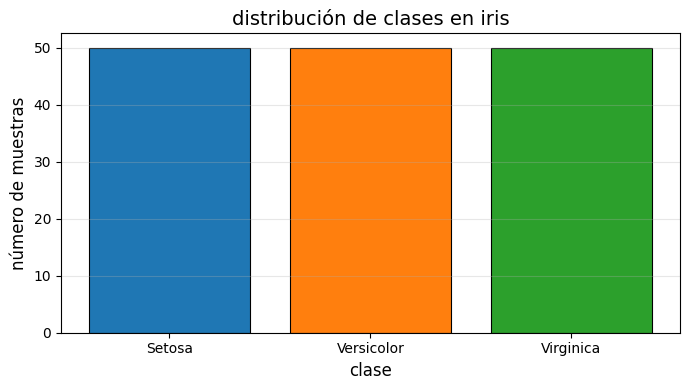

In [11]:
conteo_clases = df_iris["clase_nombre"].value_counts().reindex(["Setosa", "Versicolor", "Virginica"])

print("\ndistribución de clases")
print("-" * 60)
print(conteo_clases)

plt.figure(figsize=(7, 4))
plt.bar(conteo_clases.index, conteo_clases.values, color=[COLORES_CLASES[i] for i in range(N_CLASES)], edgecolor="black", linewidth=0.8)

plt.title("distribución de clases en iris", fontsize=14)
plt.xlabel("clase", fontsize=12)
plt.ylabel("número de muestras", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

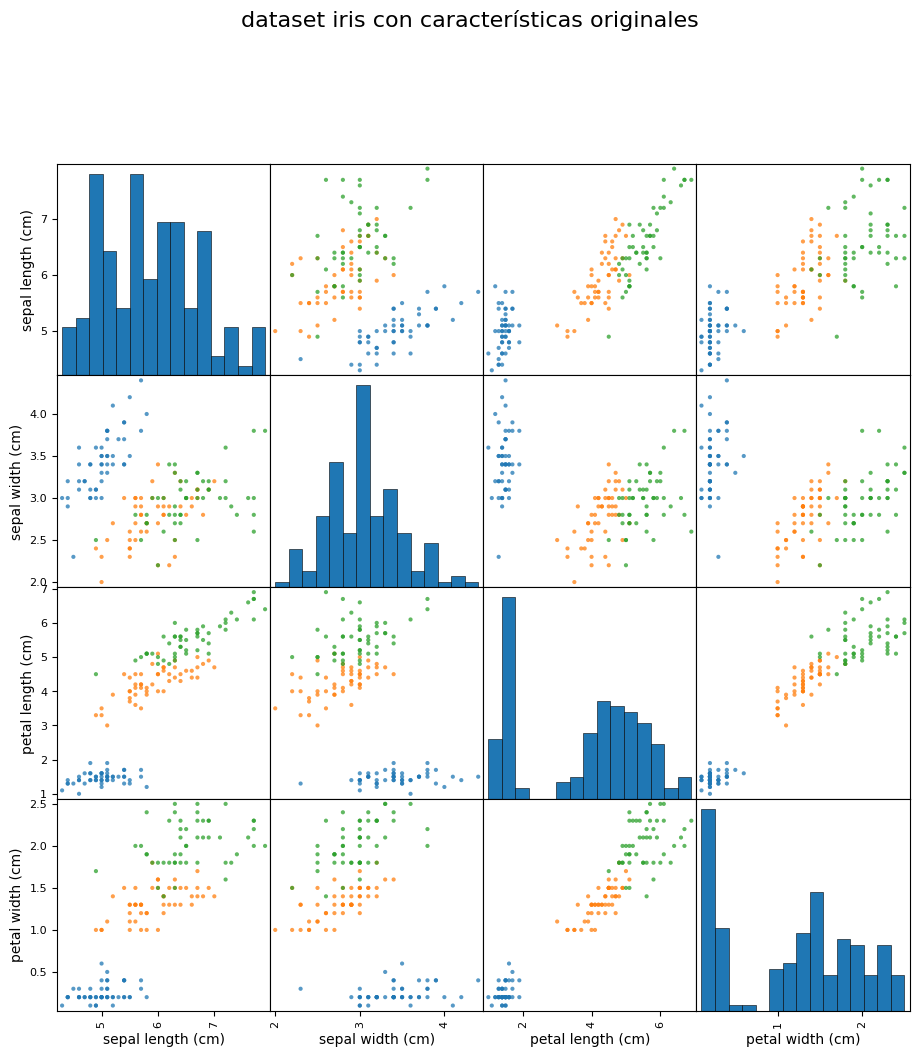

In [12]:
colores_muestras = [COLORES_CLASES[i] for i in y_raw]

axes = scatter_matrix(df_iris[iris.feature_names], figsize=(11, 11), diagonal="hist", color=colores_muestras, alpha=0.75, hist_kwds={"bins": 15, "edgecolor": "black", "linewidth": 0.4})
plt.suptitle("dataset iris con características originales", fontsize=16, y=1.02)

plt.show()

**Normalizamos datos:**

In [13]:
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X_raw)

print("\ndespués de standardscaler")
print("-" * 60)
print("forma:", X_standard.shape)
print("media aproximada por feature:", np.round(X_standard.mean(axis=0), 6))
print("desviación estándar aproximada por feature:", np.round(X_standard.std(axis=0), 6))


después de standardscaler
------------------------------------------------------------
forma: (150, 4)
media aproximada por feature: [-0. -0. -0. -0.]
desviación estándar aproximada por feature: [1. 1. 1. 1.]


**PCA a 3 componentes, parte importante para poder usar el modelo:**

In [14]:
pca_3 = PCA(n_components=3, random_state=SEMILLA)
X_pca = pca_3.fit_transform(X_standard)

print("\ndespués de pca(3)")
print("-" * 60)
print("forma:", X_pca.shape)

print("\nvarianza explicada por componente")
for i, varianza in enumerate(pca_3.explained_variance_ratio_):
    print(f"pc{i+1}: {varianza:.6f}")

print("varianza explicada acumulada:", f"{np.sum(pca_3.explained_variance_ratio_):.6f}")


después de pca(3)
------------------------------------------------------------
forma: (150, 3)

varianza explicada por componente
pc1: 0.729624
pc2: 0.228508
pc3: 0.036689
varianza explicada acumulada: 0.994821


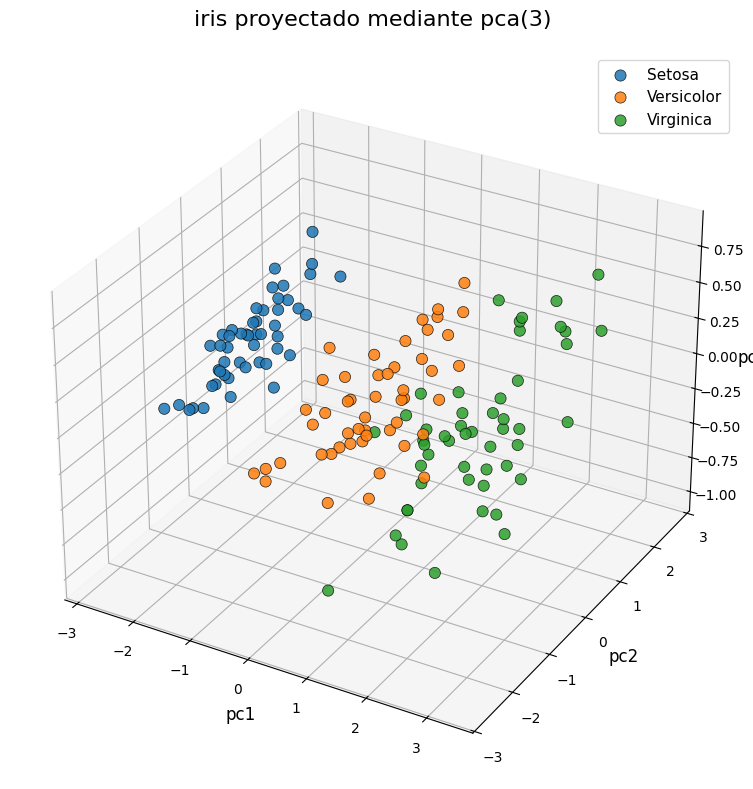

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for clase_id in range(N_CLASES):
    mascara = y_raw == clase_id
    ax.scatter(X_pca[mascara, 0], X_pca[mascara, 1], X_pca[mascara, 2], s=65, alpha=0.85, edgecolors="black", linewidth=0.5, color=COLORES_CLASES[clase_id], label=NOMBRES_CLASES[clase_id])

ax.set_title("iris proyectado mediante pca(3)", fontsize=16, pad=20)
ax.set_xlabel("pc1", fontsize=12)
ax.set_ylabel("pc2", fontsize=12)
ax.set_zlabel("pc3", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Escalado angular para entrar a la DR-QNN:**

In [16]:
scaler_angular = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_angulos = scaler_angular.fit_transform(X_pca)

print("\ndespués del escalado angular")
print("-" * 60)
print("forma final:", X_angulos.shape)

for i in range(N_FEATURES_QNN):
    print(f"x{i+1}: " f"[{X_angulos[:, i].min():.6f}, " f"{X_angulos[:, i].max():.6f}]")


después del escalado angular
------------------------------------------------------------
forma final: (150, 3)
x1: [-3.141593, 3.141593]
x2: [-3.141593, 3.141593]
x3: [-3.141593, 3.141593]


In [17]:
df_angulos = pd.DataFrame(X_angulos, columns=["x1", "x2", "x3"])

df_angulos["clase_id"] = y_raw
df_angulos["clase_nombre"] = [NOMBRES_CLASES[i] for i in y_raw]

print("\nprimeras filas del espacio angular final")
display(df_angulos.head())


primeras filas del espacio angular final


,x1,x2,x3,clase_id,clase_nombre
0,-2.615355,0.545825,0.680307,0,Setosa
1,-2.425631,-0.812100,1.040883,0,Setosa
2,-2.718123,-0.421220,0.100473,0,Setosa
3,-2.651166,-0.721812,-0.058354,0,Setosa
4,-2.744570,0.742083,0.196478,0,Setosa


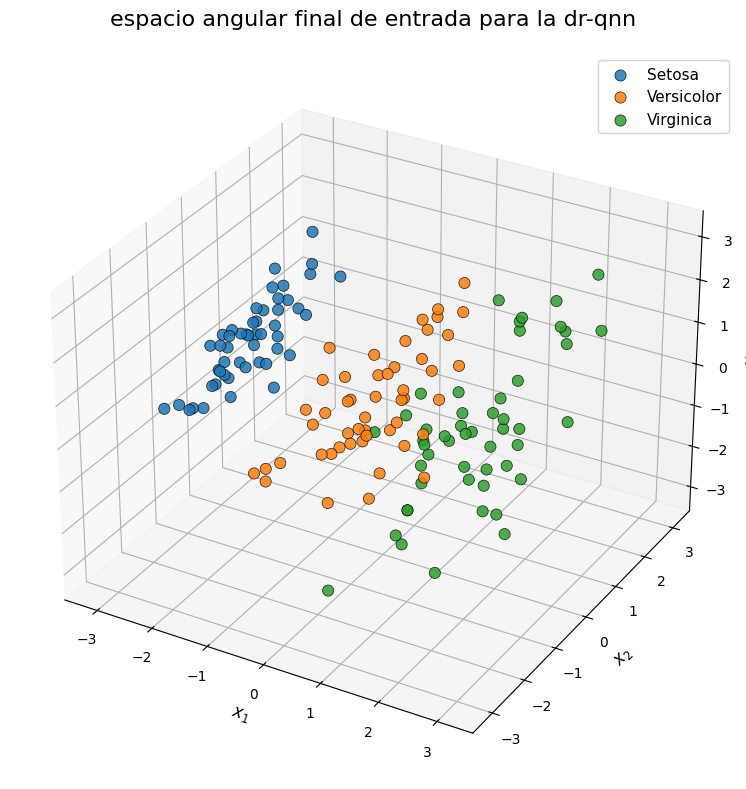

In [18]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for clase_id in range(N_CLASES):
    mascara = y_raw == clase_id

    ax.scatter(X_angulos[mascara, 0], X_angulos[mascara, 1], X_angulos[mascara, 2], s=65, alpha=0.85, edgecolors="black", linewidth=0.5, color=COLORES_CLASES[clase_id], label=NOMBRES_CLASES[clase_id])

ax.set_title("espacio angular final de entrada para la dr-qnn", fontsize=16, pad=20)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12)
ax.set_zlabel(r"$x_3$", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Antes de seguir verifico datos rapidamente:**

In [19]:
N_CLASES_DETECTADAS = len(np.unique(y_raw))

assert N_CLASES_DETECTADAS == N_CLASES, (f"error: se esperaban {N_CLASES} clases, " f"pero se detectaron {N_CLASES_DETECTADAS}.")
assert n_features_originales == 4, (f"error: iris debería tener 4 características originales, " f"pero se detectaron {n_features_originales}.")
assert X_angulos.shape[1] == N_FEATURES_QNN, (f"error: se esperaban {N_FEATURES_QNN} features para la dr-qnn, " f"pero se obtuvieron {X_angulos.shape[1]}.")
assert np.all(X_angulos >= -np.pi - 1e-8), "error: hay valores menores que -π."
assert np.all(X_angulos <= np.pi + 1e-8), "error: hay valores mayores que π."

# **3. Etiqueta multiclase (3)**

**Definamos los estados etiqueta en el qubit para cada clase:**

In [20]:
phi_0 = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=np.complex64)
phi_1 = np.array([1 / np.sqrt(2), np.exp(1j * 2 * np.pi / 3) / np.sqrt(2)], dtype=np.complex64)
phi_2 = np.array([1 / np.sqrt(2), np.exp(1j * 4 * np.pi / 3) / np.sqrt(2)], dtype=np.complex64)

print("φ0 — setosa:", phi_0)
print("φ1 — versicolor:", phi_1)
print("φ2 — virginica:", phi_2)

φ0 — setosa: [0.70710677+0.j 0.70710677+0.j]
φ1 — versicolor: [ 0.70710677+0.j         -0.35355338+0.61237246j]
φ2 — virginica: [ 0.70710677+0.j         -0.35355338-0.61237246j]


**Valido cumplir <φ|φ> = 1:**

In [21]:
normas = [np.vdot(phi_0, phi_0).real, np.vdot(phi_1, phi_1).real, np.vdot(phi_2, phi_2).real]

print("\nnormalización")
print("-" * 60)

for i, norma in enumerate(normas):
    print(f"||φ{i}||² = {norma:.6f}")
    assert np.isclose(norma, 1.0), f"φ{i} no está normalizado"


normalización
------------------------------------------------------------
||φ0||² = 1.000000
||φ1||² = 1.000000
||φ2||² = 1.000000


**Mido la fidelidad F = |<a|b>|² para ver qué tan parecidos son dos estados etiqueta:**


Por diseño y contrucción sabemos que estaán "separados" a una misma "distancia", faltaría luego automatizar a N Clases.

In [22]:
def fidelidad_np(estado_a, estado_b):
    return np.abs(np.vdot(estado_a, estado_b)) ** 2

fidelidades_etiqueta = np.array(
    [[fidelidad_np(phi_0, phi_0), fidelidad_np(phi_0, phi_1), fidelidad_np(phi_0, phi_2)], [fidelidad_np(phi_1, phi_0), fidelidad_np(phi_1, phi_1), fidelidad_np(phi_1, phi_2)], [fidelidad_np(phi_2, phi_0), fidelidad_np(phi_2, phi_1), fidelidad_np(phi_2, phi_2)]])

print("\nmatriz de fidelidades entre estados etiqueta")
print("-" * 60)
print(np.round(fidelidades_etiqueta, 6))


matriz de fidelidades entre estados etiqueta
------------------------------------------------------------
[[1.   0.25 0.25]
 [0.25 1.   0.25]
 [0.25 0.25 1.  ]]


**Convertimos los estados etiqueta a tensores de torch:**

Esto para depues utilizarlos en el loss :L = 1 - |<φy|ψθ(x)>|²

In [23]:
ESTADOS_ETIQUETA_1Q = torch.tensor(np.stack([phi_0, phi_1, phi_2], axis=0), dtype=torch.complex64, device=DISPOSITIVO)

print("\nestados etiqueta 1q")
print("-" * 60)
print("shape:", ESTADOS_ETIQUETA_1Q.shape)
print("dtype:", ESTADOS_ETIQUETA_1Q.dtype)
print("device:", ESTADOS_ETIQUETA_1Q.device)


estados etiqueta 1q
------------------------------------------------------------
shape: torch.Size([3, 2])
dtype: torch.complex64
device: cuda:0


**Extensión de estados etiqueta a 2q y a 3q:**

    i.e.
        |φc> -> |φc> ⊗ |0>          para 2 qubits
        |φc> -> |φc> ⊗ |0> ⊗ |0>   para 3 qubits

In [24]:
def extender_estado_etiqueta_np(estado_1q, n_qubits):
    estado_extendido = estado_1q.copy()
    estado_cero = np.array([1.0, 0.0], dtype=np.complex64)
    for _ in range(n_qubits - 1):
        estado_extendido = np.kron(estado_extendido, estado_cero)
    return estado_extendido.astype(np.complex64)

def construir_estados_etiqueta_torch(n_qubits):
    estados_np = np.stack(
        [extender_estado_etiqueta_np(phi_0, n_qubits), extender_estado_etiqueta_np(phi_1, n_qubits), extender_estado_etiqueta_np(phi_2, n_qubits)], axis=0)
    return torch.tensor(estados_np, dtype=torch.complex64, device=DISPOSITIVO)

ESTADOS_ETIQUETA = {1: construir_estados_etiqueta_torch(1), 2: construir_estados_etiqueta_torch(2), 3: construir_estados_etiqueta_torch(3)}

print("\nestados etiqueta extendidos")
print("-" * 60)

for n_qubits, estados in ESTADOS_ETIQUETA.items():
    print(f"{n_qubits}q -> shape {tuple(estados.shape)}")


estados etiqueta extendidos
------------------------------------------------------------
1q -> shape (3, 2)
2q -> shape (3, 4)
3q -> shape (3, 8)


- En PyTorch, la primera dimensión corresponde a las clases y la segunda almacena las amplitudes complejas del estado objetivo en la base computacional, permitiendo seleccionar directamente los estados correctos mediante ESTADOS_ETIQUETA[y_batch].

- Desde la perspectiva cuántica, estas amplitudes definen completamente cada estado etiqueta; para 1 qubit las dos columnas corresponden a |0⟩ y |1⟩, mientras que para n qubits la dimensión crece como 2^n.

**Convertir estados puros a coordenadas de bloch:**

Para |ψ> = a|0> + b|1>:
- rx = 2 Re(a* b)
- ry = 2 Im(a* b)
- rz = |a|² - |b|²

In [25]:
def estado_puro_a_bloch(estado):
    a = estado[0]
    b = estado[1]
    rx = 2 * np.real(np.conj(a) * b)
    ry = 2 * np.imag(np.conj(a) * b)
    rz = np.abs(a) ** 2 - np.abs(b) ** 2
    return float(rx), float(ry), float(rz)


bloch_phi_0 = estado_puro_a_bloch(phi_0)
bloch_phi_1 = estado_puro_a_bloch(phi_1)
bloch_phi_2 = estado_puro_a_bloch(phi_2)

estados_bloch = {0: bloch_phi_0, 1: bloch_phi_1, 2: bloch_phi_2}

print("\ncoordenadas de bloch")
print("-" * 60)
print("φ0:", bloch_phi_0)
print("φ1:", bloch_phi_1)
print("φ2:", bloch_phi_2)


coordenadas de bloch
------------------------------------------------------------
φ0: (0.9999999403953552, 0.0, 0.0)
φ1: (-0.4999999701976776, 0.866025447845459, 0.0)
φ2: (-0.4999999701976776, -0.866025447845459, 0.0)


**Visualización de estados en el plano ecuatorial:**

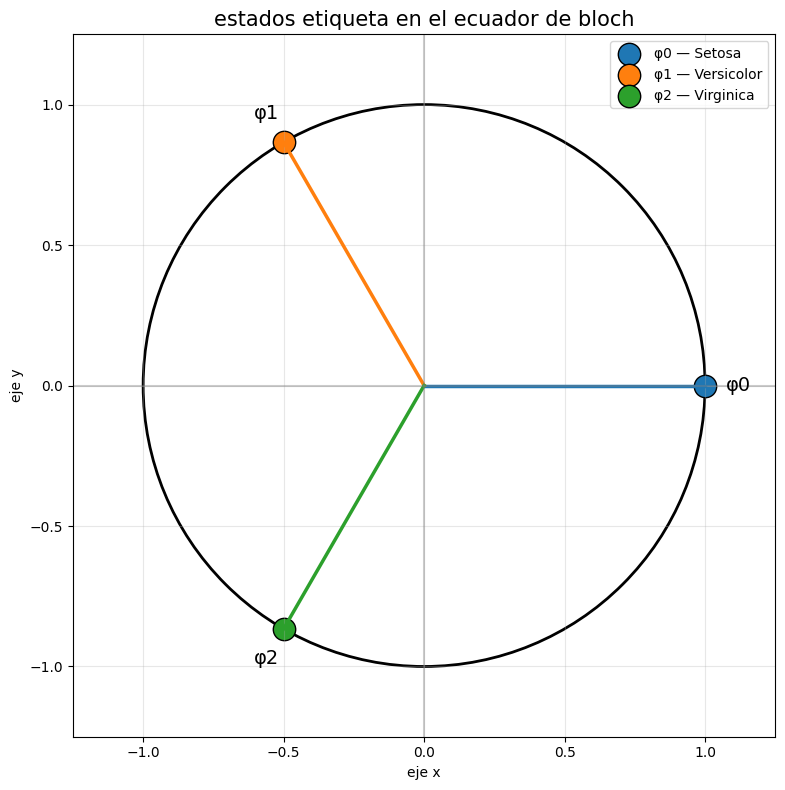

In [26]:
plt.figure(figsize=(8, 8))
circulo = plt.Circle((0, 0), 1, fill=False, linewidth=2, color="black")
plt.gca().add_patch(circulo)

for clase_id in range(N_CLASES):
    rx, ry, rz = estados_bloch[clase_id]
    plt.plot([0, rx], [0, ry], linewidth=2.5, color=COLORES_CLASES[clase_id])
    plt.scatter(rx, ry, s=260, color=COLORES_CLASES[clase_id], edgecolors="black", linewidth=1, label=f"φ{clase_id} — {NOMBRES_CLASES[clase_id]}")
    plt.text(1.12 * rx, 1.12 * ry, f"φ{clase_id}", fontsize=14, ha="center", va="center")

plt.axhline(0, color="gray", alpha=0.4)
plt.axvline(0, color="gray", alpha=0.4)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.gca().set_aspect("equal")
plt.title("estados etiqueta en el ecuador de bloch", fontsize=15)
plt.xlabel("eje x")
plt.ylabel("eje y")
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Visualización en la esfera de Bloch:**

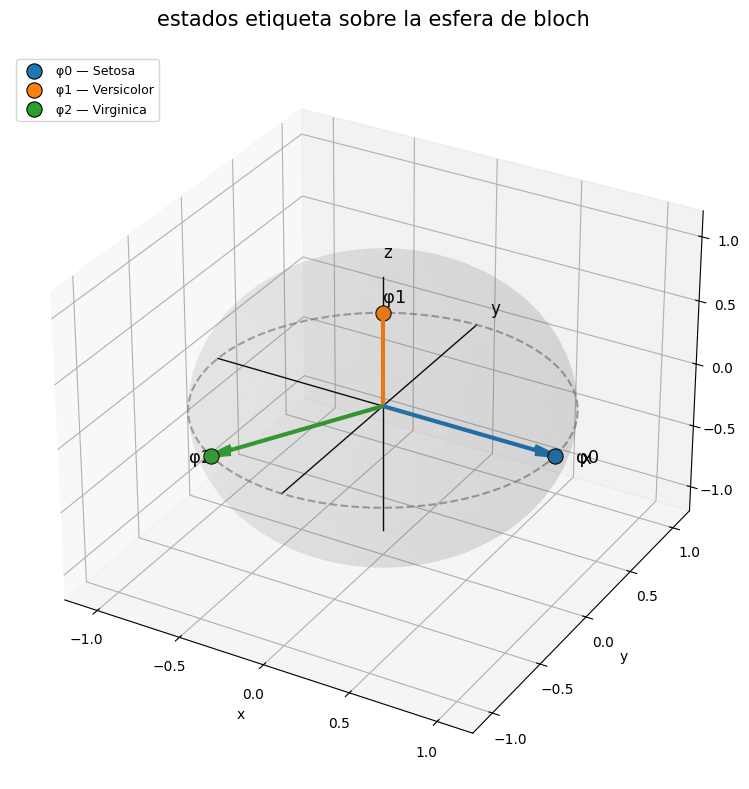

In [27]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)

x_esfera = np.outer(np.cos(u), np.sin(v))
y_esfera = np.outer(np.sin(u), np.sin(v))
z_esfera = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface( x_esfera, y_esfera, z_esfera, alpha=0.08, color="gray", linewidth=0)
ax.plot([-1, 1], [0, 0], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [-1, 1], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [0, 0], [-1, 1], color="black", linewidth=1)
ax.plot(np.cos(u), np.sin(u), np.zeros_like(u), color="gray", linestyle="--", alpha=0.7)

for clase_id in range(N_CLASES):
    rx, ry, rz = estados_bloch[clase_id]

    ax.quiver(0, 0, 0, rx, ry, rz, color=COLORES_CLASES[clase_id], linewidth=3, arrow_length_ratio=0.12)
    ax.scatter(rx, ry, rz, s=120, color=COLORES_CLASES[clase_id], edgecolors="black", linewidth=0.8, label=f"φ{clase_id} — {NOMBRES_CLASES[clase_id]}")
    ax.text(1.12 * rx, 1.12 * ry, 1.12 * rz, f"φ{clase_id}", fontsize=13)

ax.text(1.15, 0, 0, "x", fontsize=12)
ax.text(0, 1.15, 0, "y", fontsize=12)
ax.text(0, 0, 1.15, "z", fontsize=12)

ax.set_title("estados etiqueta sobre la esfera de bloch", fontsize=15, pad=20)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

**Hasta el momento tenemos:**

In [28]:
print("\nsección 3 completada")
print("-" * 60)
print("setosa      -> |φ0>")
print("versicolor  -> |φ1>")
print("virginica   -> |φ2>")
print("loss futura -> L = 1 - |<φy|ψθ(x)>|²")
print("salida futura de la dr-qnn -> |ψθ(x)>")


sección 3 completada
------------------------------------------------------------
setosa      -> |φ0>
versicolor  -> |φ1>
virginica   -> |φ2>
loss futura -> L = 1 - |<φy|ψθ(x)>|²
salida futura de la dr-qnn -> |ψθ(x)>


# **4. Separación del data set y carga de los dataloaaders** 

(Los data los formamos pensando en más adelante llevarlo a imágenes)

**Separar train, validación y test:**

- train = 60%
- val   = 20%
- test  = 20%

In [29]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_angulos, y_raw, test_size=0.20, random_state=SEMILLA, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=SEMILLA, stratify=y_train_val)

print("tamaños de los conjuntos")
print("-" * 60)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

tamaños de los conjuntos
------------------------------------------------------------
X_train: (90, 3) y_train: (90,)
X_val:   (30, 3) y_val:   (30,)
X_test:  (30, 3) y_test:  (30,)


**Veamos la partición de los datos:**

Si bien conocemos a iris, esto nos prepara para futuros datos:

In [30]:
def mostrar_distribucion(nombre, y):
    valores, conteos = np.unique(y, return_counts=True)
    print(f"\n{nombre}")
    print("-" * 60)

    for clase_id, conteo in zip(valores, conteos):
        print(f"{NOMBRES_CLASES[clase_id]:10s}: {conteo}")

mostrar_distribucion("distribución train", y_train)
mostrar_distribucion("distribución validación", y_val)
mostrar_distribucion("distribución test", y_test)


distribución train
------------------------------------------------------------
Setosa    : 30
Versicolor: 30
Virginica : 30

distribución validación
------------------------------------------------------------
Setosa    : 10
Versicolor: 10
Virginica : 10

distribución test
------------------------------------------------------------
Setosa    : 10
Versicolor: 10
Virginica : 10


**Pasemos los arrays numpy a tensores torch**

En prox. proyectos revisare su hay forma de modificar que X debe ser float32, pues por ahora es necesario para entrar como ángulos a la DR-QNN. Por otro lado y debe ser long porque se usará como índice.

In [31]:
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DISPOSITIVO)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DISPOSITIVO)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DISPOSITIVO)

y_train_t = torch.tensor(y_train, dtype=torch.long, device=DISPOSITIVO)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=DISPOSITIVO)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=DISPOSITIVO)

print("\ntensores creados")
print("-" * 60)
print("X_train_t:", X_train_t.shape, X_train_t.dtype, X_train_t.device)
print("y_train_t:", y_train_t.shape, y_train_t.dtype, y_train_t.device)
print("X_val_t:  ", X_val_t.shape,   X_val_t.dtype,   X_val_t.device)
print("y_val_t:  ", y_val_t.shape,   y_val_t.dtype,   y_val_t.device)
print("X_test_t: ", X_test_t.shape,  X_test_t.dtype,  X_test_t.device)
print("y_test_t: ", y_test_t.shape,  y_test_t.dtype,  y_test_t.device)


tensores creados
------------------------------------------------------------
X_train_t: torch.Size([90, 3]) torch.float32 cuda:0
y_train_t: torch.Size([90]) torch.int64 cuda:0
X_val_t:   torch.Size([30, 3]) torch.float32 cuda:0
y_val_t:   torch.Size([30]) torch.int64 cuda:0
X_test_t:  torch.Size([30, 3]) torch.float32 cuda:0
y_test_t:  torch.Size([30]) torch.int64 cuda:0


**Pasemos a Tensores los dataset separados, ya con su X y Y en tensor:**

In [32]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

print("\ndatasets creados")
print("-" * 60)
print("train_dataset:", len(train_dataset), "muestras")
print("val_dataset:  ", len(val_dataset), "muestras")
print("test_dataset: ", len(test_dataset), "muestras")


datasets creados
------------------------------------------------------------
train_dataset: 90 muestras
val_dataset:   30 muestras
test_dataset:  30 muestras


**Ahora construyo con Dataloaders:**

Con el Dataloader permito entrenar por batches y nos prepara para data sets más grandes como imágenes en un futuro, muy similar a la MS-HQCNN

batch de datos → DR-QNN → psi_batch → loss vectorizada

In [33]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\ndataloaders creados")
print("-" * 60)
print("batch size:", BATCH_SIZE)
print("batches train:", len(train_loader))
print("batches val:  ", len(val_loader))
print("batches test: ", len(test_loader))


dataloaders creados
------------------------------------------------------------
batch size: 32
batches train: 3
batches val:   1
batches test:  1


**Revisemos los batch**

In [34]:
x_batch_ejemplo, y_batch_ejemplo = next(iter(train_loader))

print("\nejemplo de batch")
print("-" * 60)
print("x_batch_ejemplo shape:", x_batch_ejemplo.shape)
print("y_batch_ejemplo shape:", y_batch_ejemplo.shape)
print("x_batch_ejemplo dtype:", x_batch_ejemplo.dtype)
print("y_batch_ejemplo dtype:", y_batch_ejemplo.dtype)

print("\nprimeros datos del batch")
print(x_batch_ejemplo[:5])

print("\nprimeras etiquetas del batch")
print(y_batch_ejemplo[:10])


ejemplo de batch
------------------------------------------------------------
x_batch_ejemplo shape: torch.Size([32, 3])
y_batch_ejemplo shape: torch.Size([32])
x_batch_ejemplo dtype: torch.float32
y_batch_ejemplo dtype: torch.int64

primeros datos del batch
tensor([[-2.4867, -0.6126,  0.5026],
        [-0.1129, -0.9509,  1.2683],
        [-2.6966,  1.3080, -0.1978],
        [ 0.0706, -1.1819,  0.9221],
        [ 0.1438, -2.0831,  0.3275]], device='cuda:0')

primeras etiquetas del batch
tensor([0, 1, 0, 1, 1, 1, 2, 0, 0, 1], device='cuda:0')


**Probemos ahora la selección de estados etiqueta por batch**

Si funciona, entonces Pytorch si puede seleccionar el estado objetivo por cad dato del batch.

In [35]:
phi_batch_1q = ESTADOS_ETIQUETA[1][y_batch_ejemplo]

print("\nselección de estados etiqueta para el batch")
print("-" * 60)
print("y_batch_ejemplo shape:", y_batch_ejemplo.shape)
print("phi_batch_1q shape:", phi_batch_1q.shape)

print("\ninterpretación:")
print("cada fila de phi_batch_1q es el estado etiqueta correcto")
print("para la clase indicada en y_batch_ejemplo.")


selección de estados etiqueta para el batch
------------------------------------------------------------
y_batch_ejemplo shape: torch.Size([32])
phi_batch_1q shape: torch.Size([32, 2])

interpretación:
cada fila de phi_batch_1q es el estado etiqueta correcto
para la clase indicada en y_batch_ejemplo.


**Verificación rápida de que todo salio bien conel tipo de datos y dimensiones:**

In [36]:
assert X_train_t.shape[1] == N_FEATURES_QNN
assert X_val_t.shape[1] == N_FEATURES_QNN
assert X_test_t.shape[1] == N_FEATURES_QNN

assert y_train_t.dtype == torch.long
assert y_val_t.dtype == torch.long
assert y_test_t.dtype == torch.long

assert phi_batch_1q.shape[0] == y_batch_ejemplo.shape[0]
assert phi_batch_1q.shape[1] == 2

# **5. DR-QNN y embedding**

**Configuración cuántica de simulación**

In [37]:
SHOTS = None
DIFF_METHOD = "backprop"

**Compuerta de codificación u(x)**

In [38]:
def aplicar_codificacion_datos(x, n_qubits):
    for wire in range(n_qubits):
        qml.Rot(x[0], x[1], x[2], wires=wire)

**Compuerta variacional u(theta)**

In [39]:
def aplicar_rotaciones_entrenables(theta_l, n_qubits):
    for wire in range(n_qubits):
        qml.Rot(theta_l[wire, 0], theta_l[wire, 1], theta_l[wire, 2], wires=wire)

**Bloque de enterlazamiento CRot**

In [40]:
def aplicar_entrelazamiento(phi_l, n_qubits):
    if n_qubits == 1:
        return

    for wire in range(n_qubits - 1):
        qml.CRot(phi_l[wire, 0], phi_l[wire, 1], phi_l[wire, 2], wires=[wire + 1, wire])

**Contrucción del ciruito DR-QNN**

In [41]:
def circuito_dr_qnn_estado(x, theta, phi, n_qubits):
    for capa in range(N_CAPAS):
        aplicar_codificacion_datos(x, n_qubits)
        aplicar_rotaciones_entrenables(theta[capa], n_qubits)

        if n_qubits > 1:
            aplicar_entrelazamiento(phi[capa], n_qubits)

    return qml.state()

**Modelo en pytorch de la DR-QNN como encoder cuántico**

In [42]:
class DRQNNEmbedding(nn.Module):

    def __init__(self, n_qubits, n_capas, inicializar_pequeno=True):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_capas = n_capas
        self.dimension_estado = 2 ** n_qubits

        self.dev = qml.device("default.qubit.torch", wires=n_qubits, shots=SHOTS)

        self.qnode = qml.QNode(self._circuito, self.dev, interface="torch", diff_method=DIFF_METHOD)

        escala = 0.01 if inicializar_pequeno else 1.0

        self.theta = nn.Parameter(escala * torch.randn(n_capas, n_qubits, 3, dtype=torch.float32, device=DISPOSITIVO))

        if n_qubits > 1:
            self.phi = nn.Parameter(escala * torch.randn(n_capas, n_qubits - 1, 3, dtype=torch.float32, device=DISPOSITIVO))
        else:
            self.phi = None

    def _circuito(self, x, theta, phi):
        return circuito_dr_qnn_estado(x, theta, phi, self.n_qubits)

    def forward(self, x_batch):
        estados = []

        for x in x_batch:
            phi_actual = (self.phi if self.phi is not None else torch.empty(0, dtype=torch.float32, device=DISPOSITIVO))

            estado = self.qnode(x, self.theta, phi_actual)

            estados.append(estado)

        return torch.stack(estados, dim=0)

**Función para dibujar los circuitos y sus muestras:**

In [43]:
def dibujar_circuito_modelo(modelo, x_ejemplo, titulo):
    phi_para_dibujar = (modelo.phi if modelo.phi is not None else torch.empty(0, dtype=torch.float32, device=DISPOSITIVO))

    fig, ax = qml.draw_mpl(modelo.qnode, decimals=2, style="black_white")(x_ejemplo, modelo.theta, phi_para_dibujar)

    fig.set_size_inches(14, 3 + modelo.n_qubits)
    fig.suptitle(titulo, fontsize=15, y=1.05)

    plt.tight_layout()
    plt.show()

prueba modelo 1q
------------------------------------------------------------
psi_prueba_1q shape: torch.Size([4, 2])
dtype: torch.complex128
device: cuda:0
parámetros entrenables 1q: 18

primer estado generado 1q:
tensor([ 0.9880-0.1431j, -0.0062+0.0586j], device='cuda:0',
       dtype=torch.complex128, grad_fn=<SelectBackward0>)


C:\Users\lapic\AppData\Local\Temp\ipykernel_22108\2831487519.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


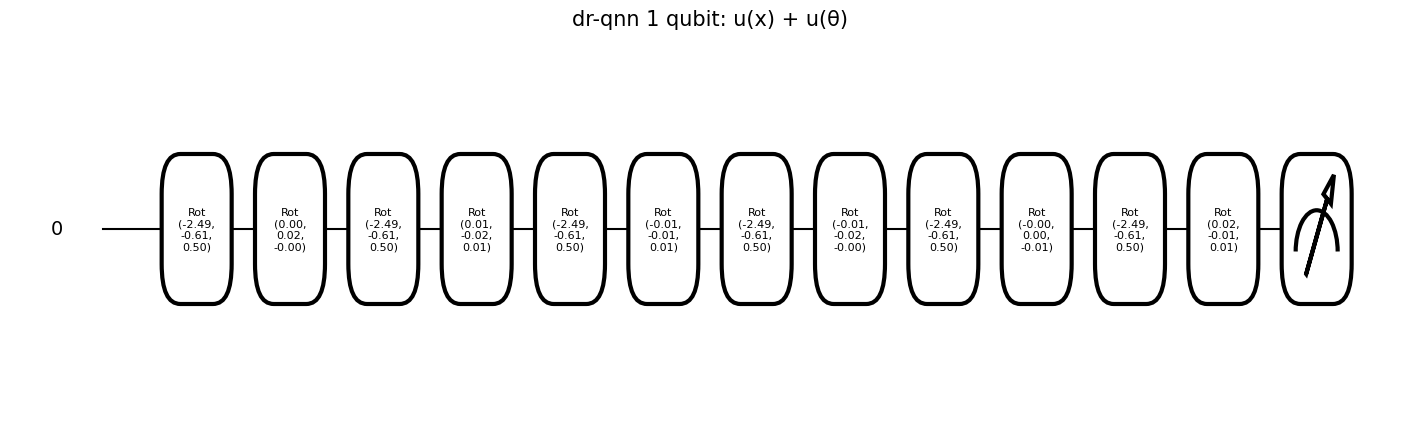

In [44]:
modelo_prueba_1q = DRQNNEmbedding(n_qubits=1, n_capas=N_CAPAS).to(DISPOSITIVO)
psi_prueba_1q = modelo_prueba_1q(x_batch_ejemplo[:4])

print("prueba modelo 1q")
print("-" * 60)
print("psi_prueba_1q shape:", psi_prueba_1q.shape)
print("dtype:", psi_prueba_1q.dtype)
print("device:", psi_prueba_1q.device)
print("parámetros entrenables 1q:", contar_parametros(modelo_prueba_1q))

print("\nprimer estado generado 1q:")
print(psi_prueba_1q[0])

dibujar_circuito_modelo(modelo_prueba_1q, x_batch_ejemplo[0], "dr-qnn 1 qubit: u(x) + u(θ)")


prueba modelo 2q
------------------------------------------------------------
psi_prueba_2q shape: torch.Size([4, 4])
dtype: torch.complex128
device: cuda:0
parámetros entrenables 2q: 54

primer estado generado 2q:
tensor([ 9.6742e-01-0.2452j,  2.2322e-03+0.0430j, -3.7064e-03+0.0461j,
         5.4166e-04+0.0020j], device='cuda:0', dtype=torch.complex128,
       grad_fn=<SelectBackward0>)


C:\Users\lapic\AppData\Local\Temp\ipykernel_22108\2831487519.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


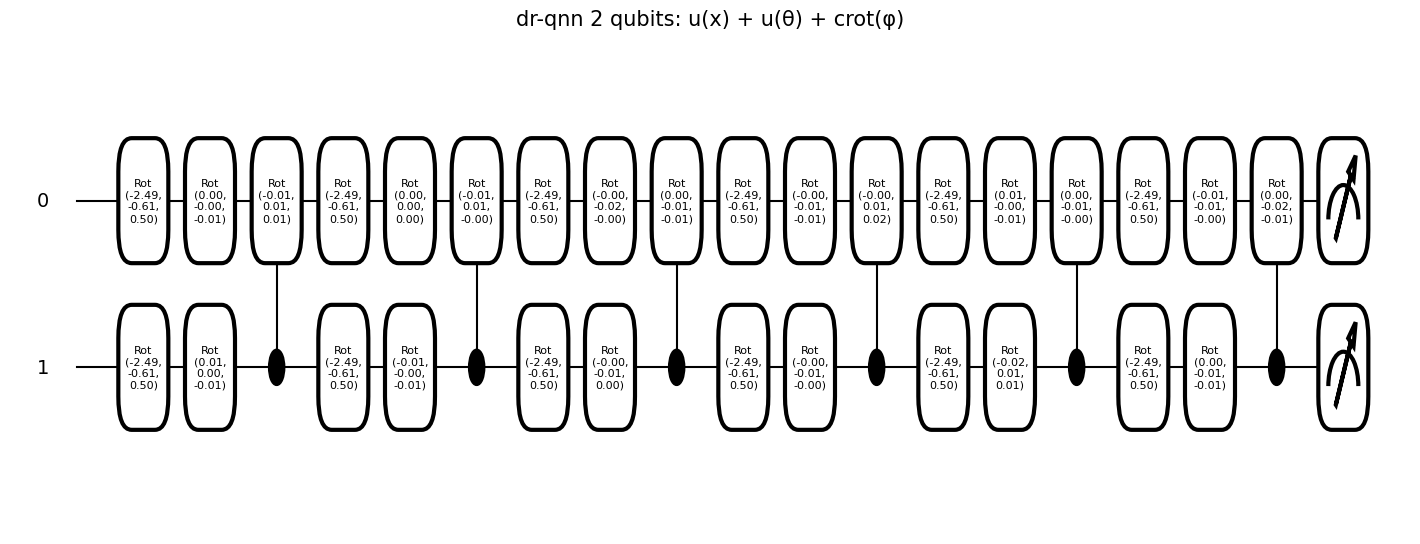

In [45]:
modelo_prueba_2q = DRQNNEmbedding(n_qubits=2, n_capas=N_CAPAS).to(DISPOSITIVO)
psi_prueba_2q = modelo_prueba_2q(x_batch_ejemplo[:4])

print("\nprueba modelo 2q")
print("-" * 60)
print("psi_prueba_2q shape:", psi_prueba_2q.shape)
print("dtype:", psi_prueba_2q.dtype)
print("device:", psi_prueba_2q.device)
print("parámetros entrenables 2q:", contar_parametros(modelo_prueba_2q))

print("\nprimer estado generado 2q:")
print(psi_prueba_2q[0])

dibujar_circuito_modelo(modelo_prueba_2q, x_batch_ejemplo[0], "dr-qnn 2 qubits: u(x) + u(θ) + crot(φ)")


prueba modelo 3q
------------------------------------------------------------
psi_prueba_3q shape: torch.Size([4, 8])
dtype: torch.complex128
device: cuda:0
parámetros entrenables 3q: 90

primer estado generado 3q:
tensor([ 9.0492e-01-4.1400e-01j,  3.5643e-02+4.2234e-02j,
         2.8262e-02+5.4539e-02j, -3.0914e-03+4.5692e-03j,
         1.8232e-02+5.0115e-02j, -2.4064e-03+1.7198e-03j,
        -4.3941e-03+6.5157e-04j, -2.1466e-04-2.8524e-04j], device='cuda:0',
       dtype=torch.complex128, grad_fn=<SelectBackward0>)


C:\Users\lapic\AppData\Local\Temp\ipykernel_22108\2831487519.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


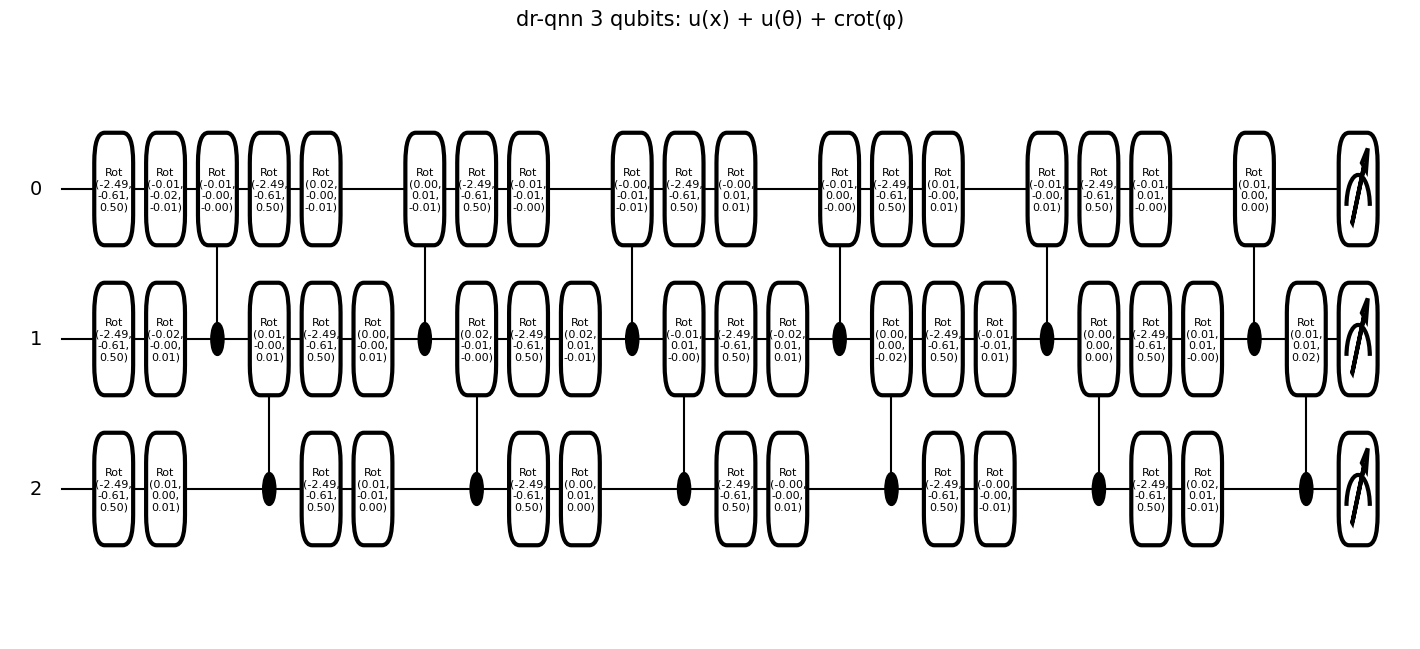

In [46]:
modelo_prueba_3q = DRQNNEmbedding(n_qubits=3, n_capas=N_CAPAS).to(DISPOSITIVO)
psi_prueba_3q = modelo_prueba_3q(x_batch_ejemplo[:4])

print("\nprueba modelo 3q")
print("-" * 60)
print("psi_prueba_3q shape:", psi_prueba_3q.shape)
print("dtype:", psi_prueba_3q.dtype)
print("device:", psi_prueba_3q.device)
print("parámetros entrenables 3q:", contar_parametros(modelo_prueba_3q))

print("\nprimer estado generado 3q:")
print(psi_prueba_3q[0])

dibujar_circuito_modelo(modelo_prueba_3q, x_batch_ejemplo[0], "dr-qnn 3 qubits: u(x) + u(θ) + crot(φ)")

**Verifiquemos que los estados generados esten bien normalizados:**

In [47]:
def norma_estado_torch(psi_batch):
    return torch.sum(torch.abs(psi_batch) ** 2, dim=1)

normas_1q = norma_estado_torch(psi_prueba_1q)
normas_2q = norma_estado_torch(psi_prueba_2q)
normas_3q = norma_estado_torch(psi_prueba_3q)

print("\nnormalización de estados generados")
print("-" * 60)
print("normas 1q:", normas_1q.detach().cpu().numpy())
print("normas 2q:", normas_2q.detach().cpu().numpy())
print("normas 3q:", normas_3q.detach().cpu().numpy())

assert torch.allclose(normas_1q, torch.ones_like(normas_1q), atol=1e-5)
assert torch.allclose(normas_2q, torch.ones_like(normas_2q), atol=1e-5)
assert torch.allclose(normas_3q, torch.ones_like(normas_3q), atol=1e-5)


normalización de estados generados
------------------------------------------------------------
normas 1q: [0.99999986 1.00000083 1.00000036 1.00000063]
normas 2q: [0.99999962 1.00000156 1.00000062 1.00000117]
normas 3q: [1.00000003 1.00000297 1.00000159 1.0000024 ]


**Verifiquemos Dimensionalidad:**

In [48]:
print("\nresumen de salida por modelo")
print("-" * 60)
print("1q -> salida psi_batch:", tuple(psi_prueba_1q.shape), "dimensión estado = 2")
print("2q -> salida psi_batch:", tuple(psi_prueba_2q.shape), "dimensión estado = 4")
print("3q -> salida psi_batch:", tuple(psi_prueba_3q.shape), "dimensión estado = 8")

print("\ninterpretación computacional")
print("-" * 60)
print("psi_batch tiene forma (batch_size, dimension_estado).")
print("cada fila es el estado complejo producido por la dr-qnn para una muestra.")


resumen de salida por modelo
------------------------------------------------------------
1q -> salida psi_batch: (4, 2) dimensión estado = 2
2q -> salida psi_batch: (4, 4) dimensión estado = 4
3q -> salida psi_batch: (4, 8) dimensión estado = 8

interpretación computacional
------------------------------------------------------------
psi_batch tiene forma (batch_size, dimension_estado).
cada fila es el estado complejo producido por la dr-qnn para una muestra.


**Liberar modelos de prueba**

In [49]:
del modelo_prueba_1q
del modelo_prueba_2q
del modelo_prueba_3q

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# **6. Métricas y funciones de entrenamiento**

**Función de fidelidad por batch**

In [50]:
def fidelidad_batch(psi_batch, y_batch, n_qubits):
    estados_etiqueta = ESTADOS_ETIQUETA[n_qubits].to(device=psi_batch.device, dtype=psi_batch.dtype)

    phi_batch = estados_etiqueta[y_batch]

    inner_products = torch.sum(torch.conj(phi_batch) * psi_batch, dim=1)

    fidelidades = torch.abs(inner_products) ** 2

    return fidelidades

**Loss de fidelidad: L = 1 - |<φy|ψθ(x)>|²**

In [51]:
def loss_fidelidad(psi_batch, y_batch, n_qubits):
    fidelidades = fidelidad_batch(psi_batch, y_batch, n_qubits)

    loss = torch.mean(1.0 - fidelidades)

    return loss

**Fidelidades contra todas las clases:**

In [52]:
def fidelidades_todas_las_clases(psi_batch, n_qubits):
    estados_etiqueta = ESTADOS_ETIQUETA[n_qubits].to(device=psi_batch.device, dtype=psi_batch.dtype)

    inner_products = torch.matmul(psi_batch, torch.conj(estados_etiqueta).T)

    fidelidades = torch.abs(inner_products) ** 2

    return fidelidades

**Accuracy temporal por argmax de fidelidades**

In [53]:
def accuracy_por_fidelidad(psi_batch, y_batch, n_qubits):
    fidelidades = fidelidades_todas_las_clases(psi_batch, n_qubits)

    y_pred = torch.argmax(fidelidades, dim=1)

    correctos = torch.sum(y_pred == y_batch).item()

    total = y_batch.shape[0]

    return correctos, total, y_pred, fidelidades

**Evaluar modelo en un dataloader**

In [54]:
def evaluar_modelo(modelo, dataloader):
    modelo.eval()

    perdida_total = 0.0
    correctos_total = 0
    muestras_total = 0

    y_reales = []
    y_preds = []

    with torch.no_grad():

        for x_batch, y_batch in dataloader:

            psi_batch = modelo(x_batch)

            loss = loss_fidelidad(psi_batch, y_batch, modelo.n_qubits)

            correctos, total, y_pred, _ = accuracy_por_fidelidad(psi_batch, y_batch, modelo.n_qubits)

            batch_size_actual = x_batch.shape[0]

            perdida_total += loss.item() * batch_size_actual
            correctos_total += correctos
            muestras_total += total

            y_reales.append(y_batch.detach().cpu())

            y_preds.append(y_pred.detach().cpu())

    perdida_promedio = perdida_total / muestras_total
    accuracy = correctos_total / muestras_total

    y_reales = torch.cat(y_reales).numpy()
    y_preds = torch.cat(y_preds).numpy()

    return perdida_promedio, accuracy, y_reales, y_preds

**Entrenar una época**

In [55]:
def entrenar_una_epoca(modelo, dataloader, optimizador):
    modelo.train()

    perdida_total = 0.0
    correctos_total = 0
    muestras_total = 0

    for x_batch, y_batch in dataloader:

        optimizador.zero_grad()

        psi_batch = modelo(x_batch)

        loss = loss_fidelidad(psi_batch, y_batch, modelo.n_qubits)

        loss.backward()
        optimizador.step()

        correctos, total, _, _ = accuracy_por_fidelidad(psi_batch.detach(), y_batch, modelo.n_qubits)

        batch_size_actual = x_batch.shape[0]

        perdida_total += loss.item() * batch_size_actual
        correctos_total += correctos
        muestras_total += total

    perdida_promedio = perdida_total / muestras_total
    accuracy = correctos_total / muestras_total

    return perdida_promedio, accuracy, muestras_total

**Ciclo completo de entrenamiento**

In [56]:
def entrenar_modelo(modelo, train_loader, val_loader, epochs, lr, nombre_modelo="modelo"):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)

    historial = {"epoch": [], "loss_train": [], "acc_train": [], "loss_val": [], "acc_val": [], "tiempo_epoca": [], "datos_procesados": []}

    tiempo_total_inicio = time.time()

    print(f"\nentrenando {nombre_modelo}")
    print("-" * 60)
    print("parámetros entrenables:", contar_parametros(modelo))
    print("n_qubits:", modelo.n_qubits)
    print("dimensión estado:", modelo.dimension_estado)
    print("epochs:", epochs)
    print("learning rate:", lr)
    print("-" * 60)

    for epoca in range(1, epochs + 1):

        inicio_epoca = time.time()

        loss_train, acc_train, datos_procesados = entrenar_una_epoca(modelo, train_loader, optimizador)

        loss_val, acc_val, _, _ = evaluar_modelo(modelo, val_loader)

        tiempo_epoca = time.time() - inicio_epoca

        historial["epoch"].append(epoca)
        historial["loss_train"].append(loss_train)
        historial["acc_train"].append(acc_train)
        historial["loss_val"].append(loss_val)
        historial["acc_val"].append(acc_val)
        historial["tiempo_epoca"].append(tiempo_epoca)
        historial["datos_procesados"].append(datos_procesados)

        if epoca % IMPRIMIR_CADA == 0:

            imprimir_resumen_epoca(epoca=epoca, total_epocas=epochs, perdida_train=loss_train, acc_train=acc_train, perdida_val=loss_val, acc_val=acc_val, tiempo_epoca=tiempo_epoca, datos_procesados=datos_procesados, total_datos=len(train_loader.dataset))

    tiempo_total = time.time() - tiempo_total_inicio

    print("-" * 60)
    print(f"entrenamiento terminado para {nombre_modelo}")
    print("tiempo total:", formato_tiempo(tiempo_total))

    return historial

**Prueba rápida de loss y accuracy con un modelo pequeño:**

In [57]:
modelo_test_1q = DRQNNEmbedding(n_qubits=1, n_capas=N_CAPAS).to(DISPOSITIVO)

psi_test = modelo_test_1q(x_batch_ejemplo[:8])

loss_test = loss_fidelidad(psi_test, y_batch_ejemplo[:8], n_qubits=1)

correctos, total, y_pred_test, fidelidades_test = accuracy_por_fidelidad(psi_test, y_batch_ejemplo[:8], n_qubits=1)

print("prueba rápida sección 6")
print("-" * 60)
print("psi_test shape:", psi_test.shape)
print("loss_test:", loss_test.item())
print("accuracy temporal:", correctos / total)
print("y real:", y_batch_ejemplo[:8].detach().cpu().numpy())
print("y pred:", y_pred_test.detach().cpu().numpy())
print("fidelidades shape:", fidelidades_test.shape)

prueba rápida sección 6
------------------------------------------------------------
psi_test shape: torch.Size([8, 2])
loss_test: 0.528377415576768
accuracy temporal: 0.25
y real: [0 1 0 1 1 1 2 0]
y pred: [1 2 2 2 2 0 2 0]
fidelidades shape: torch.Size([8, 3])


**Liberar modelo de prueba**

In [58]:
del modelo_test_1q

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# **7. Entrenamiento de la dr-qnn de 1 qubit**

**Crear modelo de 1 qubit**

In [59]:
modelo_1q = DRQNNEmbedding(n_qubits=1, n_capas=N_CAPAS).to(DISPOSITIVO)

print("modelo 1q creado")
print("-" * 60)
print("n_qubits:", modelo_1q.n_qubits)
print("dimensión estado:", modelo_1q.dimension_estado)
print("parámetros entrenables:", contar_parametros(modelo_1q))

modelo 1q creado
------------------------------------------------------------
n_qubits: 1
dimensión estado: 2
parámetros entrenables: 18


**Entrenar modelo 1q**

In [60]:
historial_1q = entrenar_modelo(modelo=modelo_1q, train_loader=train_loader, val_loader=val_loader, epochs=EPOCHS_1Q, lr=LR_1Q, nombre_modelo="dr-qnn 1q")


entrenando dr-qnn 1q
------------------------------------------------------------
parámetros entrenables: 18
n_qubits: 1
dimensión estado: 2
epochs: 20
learning rate: 0.1
------------------------------------------------------------
Época [001/020] | Datos: 90/90 | Loss train: 0.512119 | Acc train: 0.3444 | Loss val: 0.473248 | Acc val: 0.4333 | Tiempo: 2.78 s
Época [002/020] | Datos: 90/90 | Loss train: 0.396388 | Acc train: 0.4778 | Loss val: 0.447398 | Acc val: 0.4333 | Tiempo: 2.47 s
Época [003/020] | Datos: 90/90 | Loss train: 0.359827 | Acc train: 0.5222 | Loss val: 0.466051 | Acc val: 0.4000 | Tiempo: 2.47 s
Época [004/020] | Datos: 90/90 | Loss train: 0.350608 | Acc train: 0.5333 | Loss val: 0.445776 | Acc val: 0.4000 | Tiempo: 2.49 s
Época [005/020] | Datos: 90/90 | Loss train: 0.352899 | Acc train: 0.5444 | Loss val: 0.458933 | Acc val: 0.4000 | Tiempo: 2.47 s
Época [006/020] | Datos: 90/90 | Loss train: 0.340499 | Acc train: 0.6000 | Loss val: 0.459427 | Acc val: 0.3667 | Ti

**Evaluar modelo 1q en train, validación y test**

In [61]:
loss_train_1q, acc_train_1q, y_train_real_1q, y_train_pred_1q = evaluar_modelo(modelo_1q, train_loader)

loss_val_1q, acc_val_1q, y_val_real_1q, y_val_pred_1q = evaluar_modelo(modelo_1q, val_loader)

loss_test_1q, acc_test_1q, y_test_real_1q, y_test_pred_1q = evaluar_modelo(modelo_1q, test_loader)

print("\nresultados finales modelo 1q")
print("-" * 60)
print(f"train -> loss: {loss_train_1q:.6f} | acc auxiliar: {acc_train_1q:.4f}")
print(f"val   -> loss: {loss_val_1q:.6f} | acc auxiliar: {acc_val_1q:.4f}")
print(f"test  -> loss: {loss_test_1q:.6f} | acc auxiliar: {acc_test_1q:.4f}")


resultados finales modelo 1q
------------------------------------------------------------
train -> loss: 0.309018 | acc auxiliar: 0.6333
val   -> loss: 0.446005 | acc auxiliar: 0.3667
test  -> loss: 0.438896 | acc auxiliar: 0.3667


**Guardar parámetros aprendidos del modelo 1q:**

In [62]:
theta_1q_star = modelo_1q.theta.detach().clone()

print("\nparámetros aprendidos guardados")
print("-" * 60)
print("theta_1q_star shape:", theta_1q_star.shape)


parámetros aprendidos guardados
------------------------------------------------------------
theta_1q_star shape: torch.Size([6, 1, 3])


**Graficas:**

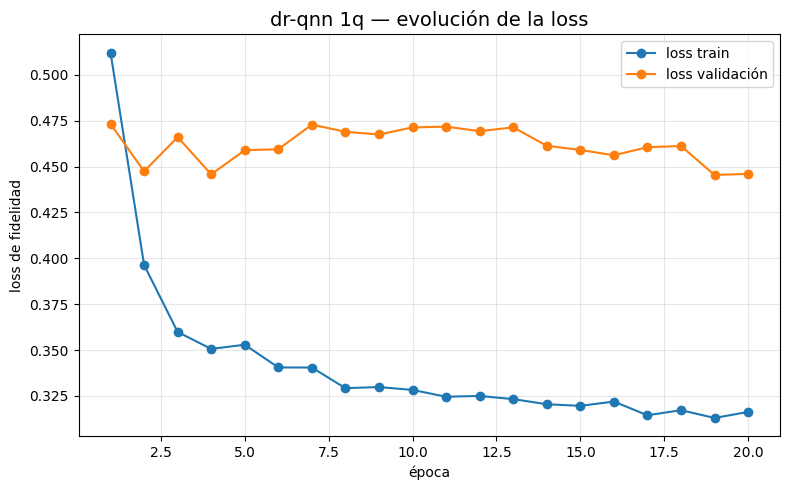

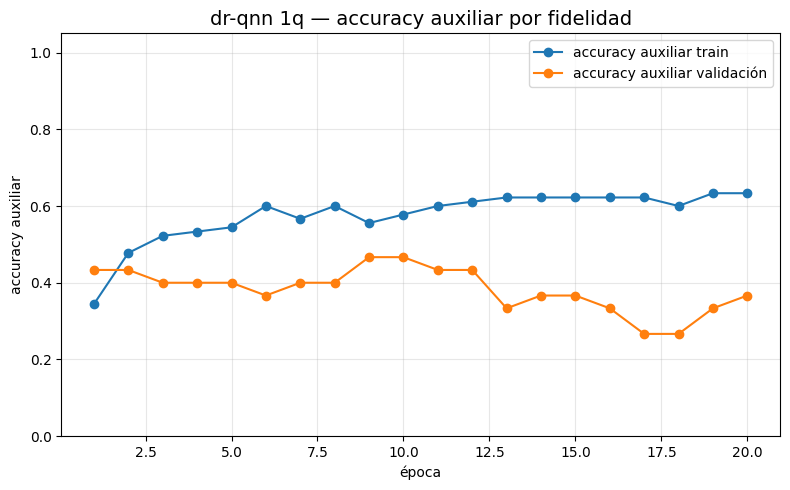

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["loss_train"], marker="o", label="loss train")

plt.plot(historial_1q["epoch"], historial_1q["loss_val"], marker="o", label="loss validación")

plt.title("dr-qnn 1q — evolución de la loss", fontsize=14)
plt.xlabel("época")
plt.ylabel("loss de fidelidad")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["acc_train"], marker="o", label="accuracy auxiliar train")

plt.plot(historial_1q["epoch"], historial_1q["acc_val"], marker="o", label="accuracy auxiliar validación")

plt.title("dr-qnn 1q — accuracy auxiliar por fidelidad", fontsize=14)
plt.xlabel("época")
plt.ylabel("accuracy auxiliar")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Graficar tiempo por época**

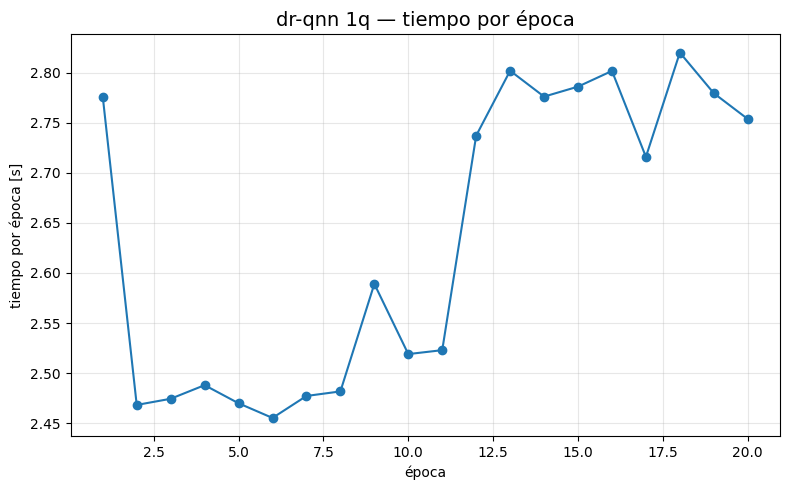


tiempo promedio por época 1q:
2.6347 s


In [64]:
plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["tiempo_epoca"], marker="o")

plt.title("dr-qnn 1q — tiempo por época", fontsize=14)
plt.xlabel("época")
plt.ylabel("tiempo por época [s]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\ntiempo promedio por época 1q:")
print(f"{np.mean(historial_1q['tiempo_epoca']):.4f} s")

**Matriz de confusión en test**

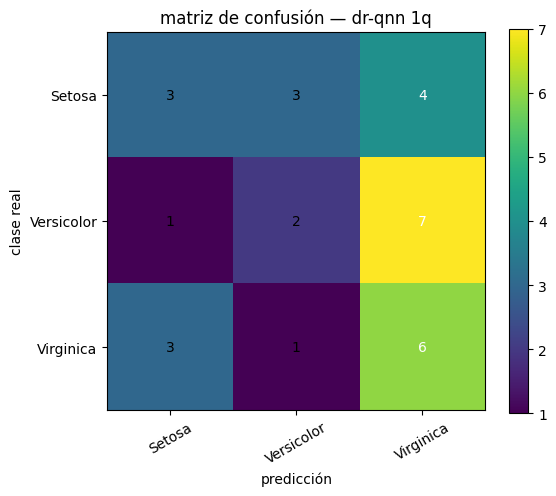

In [65]:
cm_1q = confusion_matrix(y_test_real_1q, y_test_pred_1q)

plt.figure(figsize=(6, 5))

plt.imshow( cm_1q, interpolation="nearest")

plt.title("matriz de confusión — dr-qnn 1q")
plt.colorbar()

ticks = np.arange(N_CLASES)

plt.xticks(ticks, [NOMBRES_CLASES[i] for i in range(N_CLASES)], rotation=30)

plt.yticks(ticks, [NOMBRES_CLASES[i] for i in range(N_CLASES)])

for i in range(N_CLASES):
    for j in range(N_CLASES):
        plt.text(j, i, cm_1q[i, j], ha="center", va="center", color="white" if cm_1q[i, j] > cm_1q.max() / 2 else "black")

plt.xlabel("predicción")
plt.ylabel("clase real")
plt.tight_layout()
plt.show()

**Reporte de clasificación en test:**

In [66]:
print("\nreporte de clasificación — test 1q")
print("-" * 60)

print(classification_report(y_test_real_1q, y_test_pred_1q, target_names=[NOMBRES_CLASES[i] for i in range(N_CLASES)]))


reporte de clasificación — test 1q
------------------------------------------------------------
              precision    recall  f1-score   support

      Setosa       0.43      0.30      0.35        10
  Versicolor       0.33      0.20      0.25        10
   Virginica       0.35      0.60      0.44        10

    accuracy                           0.37        30
   macro avg       0.37      0.37      0.35        30
weighted avg       0.37      0.37      0.35        30



**Obtener embeddings para train, val y test:**

In [67]:
def obtener_embeddings(modelo, dataloader):
    modelo.eval()

    estados = []
    etiquetas = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            psi_batch = modelo(x_batch)

            estados.append(psi_batch.detach().cpu())

            etiquetas.append(y_batch.detach().cpu())

    estados = torch.cat(estados, dim=0)
    etiquetas = torch.cat(etiquetas, dim=0)

    return estados, etiquetas


psi_train_1q, y_train_emb_1q = obtener_embeddings(modelo_1q, train_loader)

psi_val_1q, y_val_emb_1q = obtener_embeddings(modelo_1q, val_loader)

psi_test_1q, y_test_emb_1q = obtener_embeddings(modelo_1q, test_loader)

print("\nembeddings generados con θ*_1q")
print("-" * 60)
print("psi_train_1q:", psi_train_1q.shape)
print("psi_val_1q:  ", psi_val_1q.shape)
print("psi_test_1q: ", psi_test_1q.shape)


embeddings generados con θ*_1q
------------------------------------------------------------
psi_train_1q: torch.Size([90, 2])
psi_val_1q:   torch.Size([30, 2])
psi_test_1q:  torch.Size([30, 2])


**Convertir embeddings 1q a coordenadas de bloch:**

In [68]:
def batch_estados_1q_a_bloch(psi_batch):
    psi_np = psi_batch.numpy()

    coords = []

    for estado in psi_np:coords.append(estado_puro_a_bloch(estado))

    return np.array(coords)


bloch_train_1q = batch_estados_1q_a_bloch(psi_train_1q)

bloch_val_1q = batch_estados_1q_a_bloch(psi_val_1q)

bloch_test_1q = batch_estados_1q_a_bloch(psi_test_1q)

print("\ncoordenadas de bloch generadas")
print("-" * 60)
print("bloch_train_1q:", bloch_train_1q.shape)
print("bloch_val_1q:  ", bloch_val_1q.shape)
print("bloch_test_1q: ", bloch_test_1q.shape)


coordenadas de bloch generadas
------------------------------------------------------------
bloch_train_1q: (90, 3)
bloch_val_1q:   (30, 3)
bloch_test_1q:  (30, 3)


**Visualizar embeddings aprendidos en esfera de bloch:**

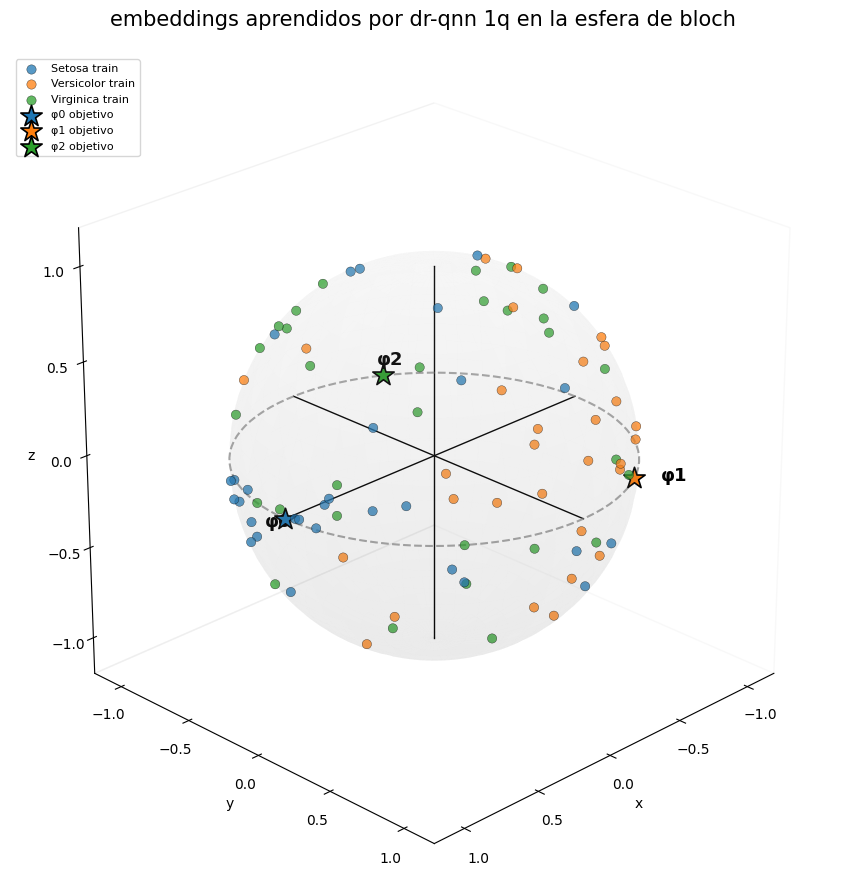

In [69]:
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 60)

x_esfera = np.outer(np.cos(u), np.sin(v))
y_esfera = np.outer(np.sin(u), np.sin(v))
z_esfera = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x_esfera, y_esfera, z_esfera, alpha=0.06, color="lightgray", linewidth=0)

ax.plot([-1, 1], [0, 0], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [-1, 1], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [0, 0], [-1, 1], color="black", linewidth=1)

ax.plot(np.cos(u), np.sin(u), np.zeros_like(u), linestyle="--", linewidth=1.5, color="gray", alpha=0.7)

# puntos aprendidos

for clase_id in range(N_CLASES):
    mascara = y_train_emb_1q.numpy() == clase_id

    ax.scatter(bloch_train_1q[mascara, 0], bloch_train_1q[mascara, 1], bloch_train_1q[mascara, 2], s=45, alpha=0.75, color=COLORES_CLASES[clase_id], edgecolors="black", linewidth=0.3, label=f"{NOMBRES_CLASES[clase_id]} train")

# estados etiqueta objetivo

for clase_id in range(N_CLASES):
    rx, ry, rz = estados_bloch[clase_id]

    ax.scatter(rx, ry, rz, s=260, color=COLORES_CLASES[clase_id], edgecolors="black", linewidth=1.2, marker="*", label=f"φ{clase_id} objetivo")

    ax.text(1.13 * rx, 1.13 * ry, 1.13 * rz, f"φ{clase_id}", fontsize=13, weight="bold")

ax.set_title("embeddings aprendidos por dr-qnn 1q en la esfera de bloch", fontsize=15, pad=20)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.grid(False)

ax.view_init(elev=25, azim=45)

ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

**Resumen:**

In [70]:
resumen_1q = {"modelo": "dr-qnn 1q", "n_qubits": 1, "dim_estado": modelo_1q.dimension_estado, "parametros": contar_parametros(modelo_1q), "loss_train": loss_train_1q, "acc_train_aux": acc_train_1q, "loss_val": loss_val_1q, "acc_val_aux": acc_val_1q, "loss_test": loss_test_1q, "acc_test_aux": acc_test_1q, "tiempo_promedio_epoca": np.mean(historial_1q["tiempo_epoca"]), "tiempo_total": np.sum(historial_1q["tiempo_epoca"])}

print("\nresumen modelo 1q")
print("-" * 60)

for clave, valor in resumen_1q.items():
    print(f"{clave}: {valor}")


resumen modelo 1q
------------------------------------------------------------
modelo: dr-qnn 1q
n_qubits: 1
dim_estado: 2
parametros: 18
loss_train: 0.30901804588435833
acc_train_aux: 0.6333333333333333
loss_val: 0.44600478092769424
acc_val_aux: 0.36666666666666664
loss_test: 0.43889644718571746
acc_test_aux: 0.36666666666666664
tiempo_promedio_epoca: 2.6347247838973997
tiempo_total: 52.694495677948


# **8. Entrenamiento de la dr-qnn de 2 qubit**

**Crear modelo de 2 qubits**

In [71]:
modelo_2q = DRQNNEmbedding(n_qubits=2, n_capas=N_CAPAS).to(DISPOSITIVO)

print("modelo 2q creado")
print("-" * 60)
print("n_qubits:", modelo_2q.n_qubits)
print("dimensión estado:", modelo_2q.dimension_estado)
print("parámetros entrenables:", contar_parametros(modelo_2q))

modelo 2q creado
------------------------------------------------------------
n_qubits: 2
dimensión estado: 4
parámetros entrenables: 54


**Inicializar 2q usando 1a:**

In [72]:
with torch.no_grad():modelo_2q.theta[:, 0, :] = theta_1q_star[:, 0, :]

print("\ntransferencia realizada")
print("-" * 60)
print("theta_1q_star copiado al primer qubit del modelo 2q")
print("theta modelo 2q:", modelo_2q.theta.shape)
print("phi modelo 2q:", modelo_2q.phi.shape)


transferencia realizada
------------------------------------------------------------
theta_1q_star copiado al primer qubit del modelo 2q
theta modelo 2q: torch.Size([6, 2, 3])
phi modelo 2q: torch.Size([6, 1, 3])


**Entrenar model 2q:**

In [73]:
historial_2q = entrenar_modelo(modelo=modelo_2q, train_loader=train_loader, val_loader=val_loader, epochs=EPOCHS_2Q, lr=LR_NQ, nombre_modelo="dr-qnn 2q")


entrenando dr-qnn 2q
------------------------------------------------------------
parámetros entrenables: 54
n_qubits: 2
dimensión estado: 4
epochs: 15
learning rate: 0.05
------------------------------------------------------------
Época [001/015] | Datos: 90/90 | Loss train: 0.428394 | Acc train: 0.5778 | Loss val: 0.556170 | Acc val: 0.3667 | Tiempo: 6.79 s
Época [002/015] | Datos: 90/90 | Loss train: 0.385326 | Acc train: 0.6111 | Loss val: 0.574818 | Acc val: 0.3000 | Tiempo: 6.72 s
Época [003/015] | Datos: 90/90 | Loss train: 0.380760 | Acc train: 0.6111 | Loss val: 0.592086 | Acc val: 0.2333 | Tiempo: 6.90 s
Época [004/015] | Datos: 90/90 | Loss train: 0.378062 | Acc train: 0.6333 | Loss val: 0.590568 | Acc val: 0.2667 | Tiempo: 7.02 s
Época [005/015] | Datos: 90/90 | Loss train: 0.374824 | Acc train: 0.6333 | Loss val: 0.592632 | Acc val: 0.3000 | Tiempo: 6.80 s
Época [006/015] | Datos: 90/90 | Loss train: 0.368206 | Acc train: 0.6333 | Loss val: 0.593139 | Acc val: 0.3000 | T

**Evaluar modelo 2q:**

In [74]:
loss_train_2q, acc_train_2q, y_train_real_2q, y_train_pred_2q = evaluar_modelo(modelo_2q, train_loader)

loss_val_2q, acc_val_2q, y_val_real_2q, y_val_pred_2q = evaluar_modelo(modelo_2q, val_loader)

loss_test_2q, acc_test_2q, y_test_real_2q, y_test_pred_2q = evaluar_modelo(modelo_2q, test_loader)

print("\nresultados finales modelo 2q")
print("-" * 60)
print(f"train -> loss: {loss_train_2q:.6f} | acc auxiliar: {acc_train_2q:.4f}")
print(f"val   -> loss: {loss_val_2q:.6f} | acc auxiliar: {acc_val_2q:.4f}")
print(f"test  -> loss: {loss_test_2q:.6f} | acc auxiliar: {acc_test_2q:.4f}")


resultados finales modelo 2q
------------------------------------------------------------
train -> loss: 0.354487 | acc auxiliar: 0.6556
val   -> loss: 0.595973 | acc auxiliar: 0.3000
test  -> loss: 0.517143 | acc auxiliar: 0.4333


**Guardar parámetros aprendidos:**

In [75]:
theta_2q_star = modelo_2q.theta.detach().clone()
phi_2q_star = modelo_2q.phi.detach().clone()

print("\nparámetros aprendidos guardados")
print("-" * 60)
print("theta_2q_star shape:", theta_2q_star.shape)
print("phi_2q_star shape:", phi_2q_star.shape)


parámetros aprendidos guardados
------------------------------------------------------------
theta_2q_star shape: torch.Size([6, 2, 3])
phi_2q_star shape: torch.Size([6, 1, 3])


**Graficas:**

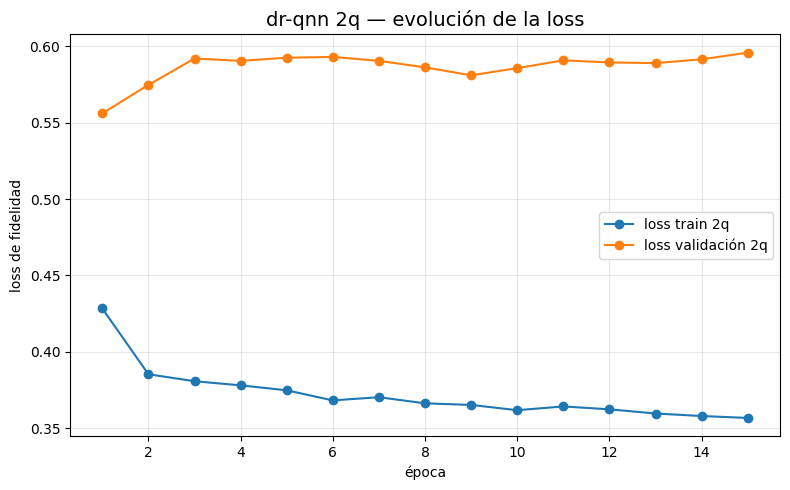

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(historial_2q["epoch"], historial_2q["loss_train"], marker="o", label="loss train 2q")

plt.plot(historial_2q["epoch"], historial_2q["loss_val"], marker="o", label="loss validación 2q")

plt.title("dr-qnn 2q — evolución de la loss", fontsize=14)
plt.xlabel("época")
plt.ylabel("loss de fidelidad")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

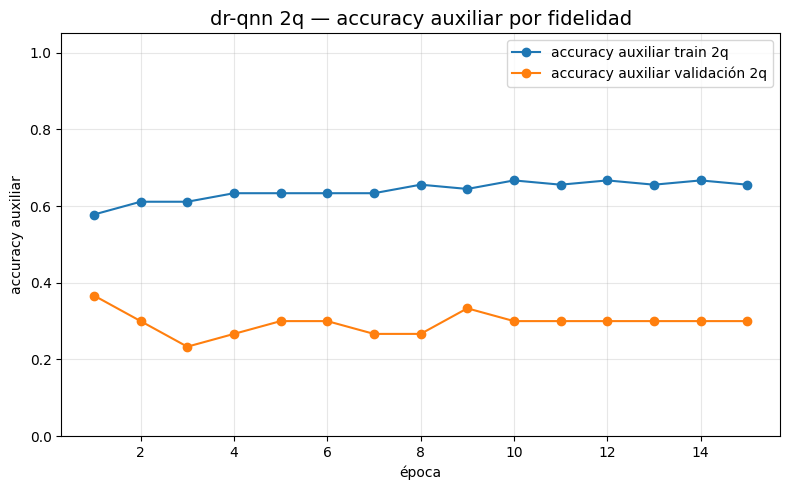

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(historial_2q["epoch"], historial_2q["acc_train"], marker="o", label="accuracy auxiliar train 2q")

plt.plot(historial_2q["epoch"], historial_2q["acc_val"], marker="o", label="accuracy auxiliar validación 2q")

plt.title("dr-qnn 2q — accuracy auxiliar por fidelidad", fontsize=14)
plt.xlabel("época")
plt.ylabel("accuracy auxiliar")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Comparación de curvas 1q vs 2q**:

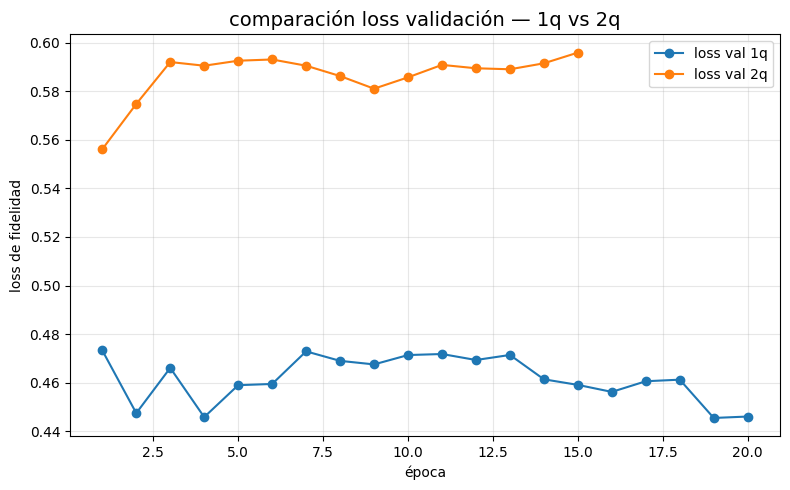

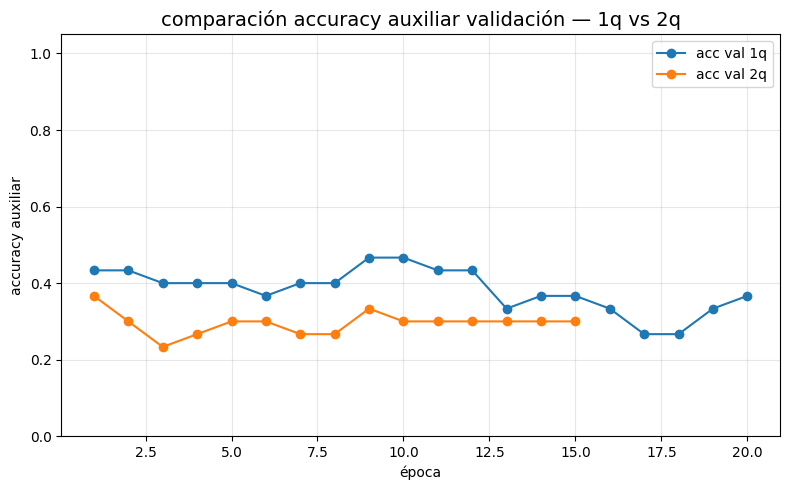

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["loss_val"], marker="o", label="loss val 1q")

plt.plot(historial_2q["epoch"], historial_2q["loss_val"], marker="o", label="loss val 2q")

plt.title("comparación loss validación — 1q vs 2q", fontsize=14)
plt.xlabel("época")
plt.ylabel("loss de fidelidad")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["acc_val"], marker="o", label="acc val 1q")

plt.plot(historial_2q["epoch"], historial_2q["acc_val"], marker="o", label="acc val 2q")

plt.title("comparación accuracy auxiliar validación — 1q vs 2q", fontsize=14)
plt.xlabel("época")
plt.ylabel("accuracy auxiliar")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Matriz de confusión en test 2q:**

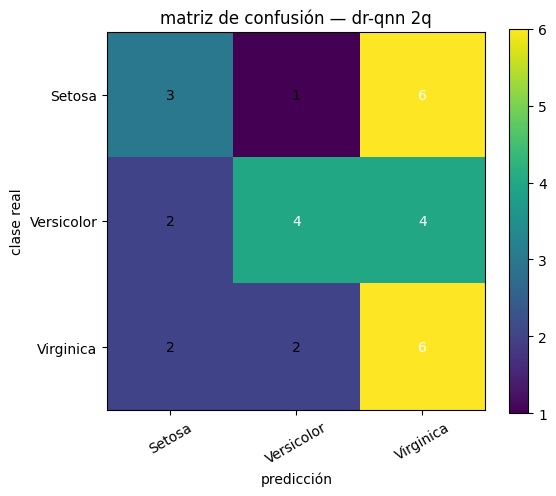

In [79]:
cm_2q = confusion_matrix(y_test_real_2q, y_test_pred_2q)

plt.figure(figsize=(6, 5))

plt.imshow(cm_2q, interpolation="nearest")

plt.title("matriz de confusión — dr-qnn 2q")
plt.colorbar()

ticks = np.arange(N_CLASES)

plt.xticks(ticks,[NOMBRES_CLASES[i] for i in range(N_CLASES)], rotation=30)

plt.yticks(ticks,[NOMBRES_CLASES[i] for i in range(N_CLASES)])

for i in range(N_CLASES):
    for j in range(N_CLASES):
        plt.text(j,i,cm_2q[i, j],ha="center",va="center",color="white" if cm_2q[i, j] > cm_2q.max() / 2 else "black")

plt.xlabel("predicción")
plt.ylabel("clase real")
plt.tight_layout()
plt.show()

**Reporte de clasificación en test 2q:**

In [80]:
print("\nreporte de clasificación — test 2q")
print("-" * 60)

print(
    classification_report(y_test_real_2q,y_test_pred_2q,target_names=[NOMBRES_CLASES[i] for i in range(N_CLASES)]))


reporte de clasificación — test 2q
------------------------------------------------------------
              precision    recall  f1-score   support

      Setosa       0.43      0.30      0.35        10
  Versicolor       0.57      0.40      0.47        10
   Virginica       0.38      0.60      0.46        10

    accuracy                           0.43        30
   macro avg       0.46      0.43      0.43        30
weighted avg       0.46      0.43      0.43        30



**Obtener embeddings |ψθ(x)> del modelo 2q:**

In [81]:
psi_train_2q, y_train_emb_2q = obtener_embeddings(modelo_2q,train_loader)

psi_val_2q, y_val_emb_2q = obtener_embeddings(modelo_2q,val_loader)

psi_test_2q, y_test_emb_2q = obtener_embeddings(modelo_2q,test_loader)

print("\nembeddings generados con θ*_2q y φ*_2q")
print("-" * 60)
print("psi_train_2q:", psi_train_2q.shape)
print("psi_val_2q:  ", psi_val_2q.shape)
print("psi_test_2q: ", psi_test_2q.shape)


embeddings generados con θ*_2q y φ*_2q
------------------------------------------------------------
psi_train_2q: torch.Size([90, 4])
psi_val_2q:   torch.Size([30, 4])
psi_test_2q:  torch.Size([30, 4])


**Convertir estado 2q a bloch del primer qubit:**

In [82]:
def estado_2q_a_bloch_qubit_0(estado):
    psi = np.asarray(estado, dtype=np.complex128).reshape(2, 2)

    rho_0 = psi @ np.conjugate(psi).T

    rx = 2 * np.real(rho_0[0, 1])
    ry = -2 * np.imag(rho_0[0, 1])
    rz = np.real(rho_0[0, 0] - rho_0[1, 1])

    return float(rx), float(ry), float(rz)


def batch_estados_2q_a_bloch_qubit_0(psi_batch):
    psi_np = psi_batch.numpy()

    coords = []

    for estado in psi_np:
        coords.append(estado_2q_a_bloch_qubit_0(estado))

    return np.array(coords)


bloch_train_2q = batch_estados_2q_a_bloch_qubit_0(psi_train_2q)

bloch_val_2q = batch_estados_2q_a_bloch_qubit_0(psi_val_2q)

bloch_test_2q = batch_estados_2q_a_bloch_qubit_0(psi_test_2q)

print("\ncoordenadas de bloch reducidas del primer qubit")
print("-" * 60)
print("bloch_train_2q:", bloch_train_2q.shape)
print("bloch_val_2q:  ", bloch_val_2q.shape)
print("bloch_test_2q: ", bloch_test_2q.shape)


coordenadas de bloch reducidas del primer qubit
------------------------------------------------------------
bloch_train_2q: (90, 3)
bloch_val_2q:   (30, 3)
bloch_test_2q:  (30, 3)


**Visualizar embeddings 2q en esfera de bloch reducida:**

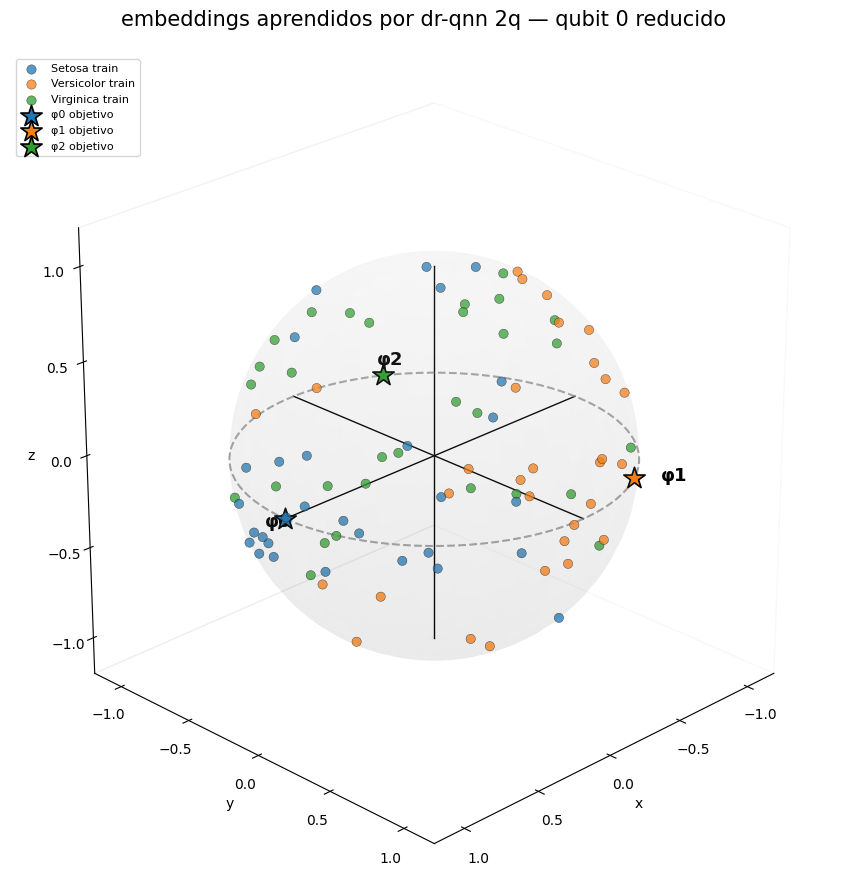

In [83]:
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 60)

x_esfera = np.outer(np.cos(u), np.sin(v))
y_esfera = np.outer(np.sin(u), np.sin(v))
z_esfera = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_esfera,
    y_esfera,
    z_esfera,
    alpha=0.06,
    color="lightgray",
    linewidth=0
)

ax.plot([-1, 1], [0, 0], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [-1, 1], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [0, 0], [-1, 1], color="black", linewidth=1)

ax.plot(
    np.cos(u),
    np.sin(u),
    np.zeros_like(u),
    linestyle="--",
    linewidth=1.5,
    color="gray",
    alpha=0.7
)

for clase_id in range(N_CLASES):
    mascara = y_train_emb_2q.numpy() == clase_id

    ax.scatter(
        bloch_train_2q[mascara, 0],
        bloch_train_2q[mascara, 1],
        bloch_train_2q[mascara, 2],
        s=45,
        alpha=0.75,
        color=COLORES_CLASES[clase_id],
        edgecolors="black",
        linewidth=0.3,
        label=f"{NOMBRES_CLASES[clase_id]} train"
    )

for clase_id in range(N_CLASES):
    rx, ry, rz = estados_bloch[clase_id]

    ax.scatter(
        rx,
        ry,
        rz,
        s=260,
        color=COLORES_CLASES[clase_id],
        edgecolors="black",
        linewidth=1.2,
        marker="*",
        label=f"φ{clase_id} objetivo"
    )

    ax.text(
        1.13 * rx,
        1.13 * ry,
        1.13 * rz,
        f"φ{clase_id}",
        fontsize=13,
        weight="bold"
    )

ax.set_title(
    "embeddings aprendidos por dr-qnn 2q — qubit 0 reducido",
    fontsize=15,
    pad=20
)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.grid(False)

ax.view_init(elev=25, azim=45)

ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

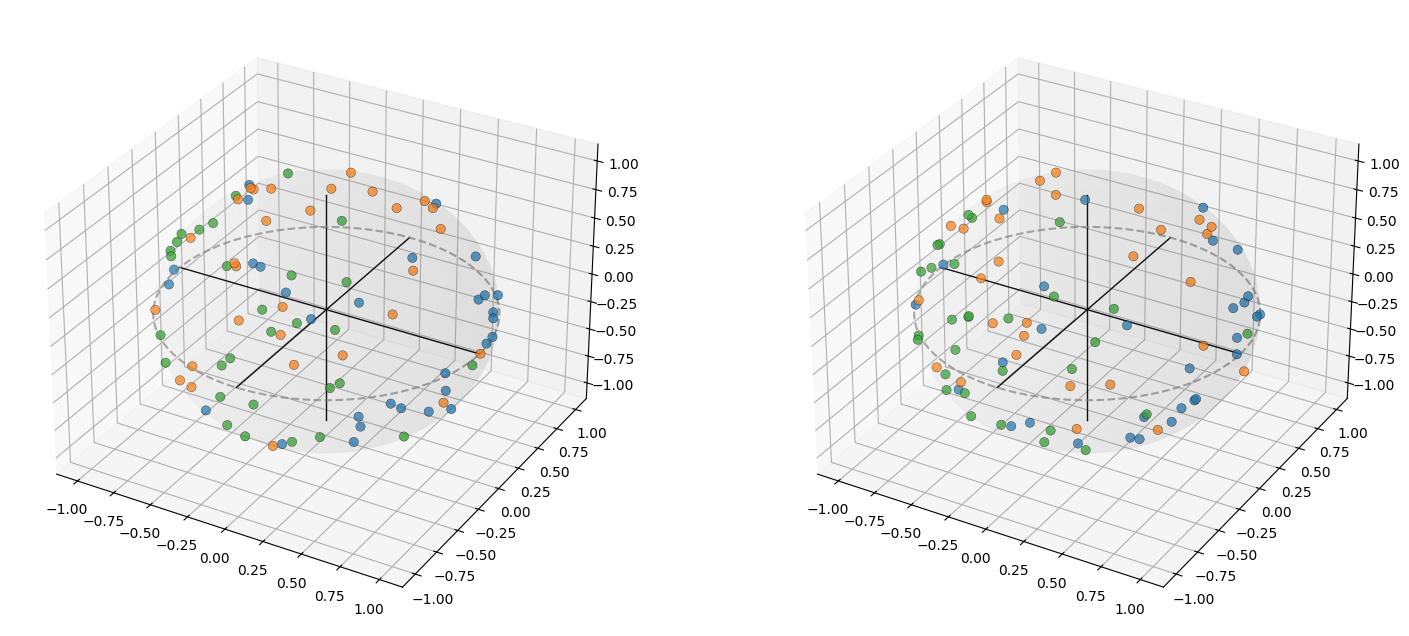

In [84]:
fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

for ax, bloch_data, y_emb, titulo in [
    (ax1, bloch_train_1q, y_train_emb_1q, "dr-qnn 1q"),
    (ax2, bloch_train_2q, y_train_emb_2q, "dr-qnn 2q — qubit 0 reducido")
]:

    ax.plot_surface(
        x_esfera,
        y_esfera,
        z_esfera,
        alpha=0.06,
        color="lightgray",
        linewidth=0
    )

    ax.plot([-1, 1], [0, 0], [0, 0], color="black", linewidth=1)
    ax.plot([0, 0], [-1, 1], [0, 0], color="black", linewidth=1)
    ax.plot([0, 0], [0, 0], [-1, 1], color="black", linewidth=1)

    ax.plot(
        np.cos(u),
        np.sin(u),
        np.zeros_like(u),
        linestyle="--",
        linewidth=1.5,
        color="gray",
        alpha=0.7
    )

    for clase_id in range(N_CLASES):
        mascara = y_emb.numpy() == clase_id

        ax.scatter(
            bloch_data[mascara, 0],
            bloch_data[mascara, 1],
            bloch_data[mascara, 2],
            s=45,
            alpha=0.75,
            color=COLORES_CLASES[clase_id],
            edgecolors="black",
            linewidth=0.3,
            label=NOMBRES_CLASES[clase_id]
        )

**Resumen:**

In [85]:
resumen_2q = {
    "modelo": "dr-qnn 2q",
    "n_qubits": 2,
    "dim_estado": modelo_2q.dimension_estado,
    "parametros": contar_parametros(modelo_2q),
    "loss_train": loss_train_2q,
    "acc_train_aux": acc_train_2q,
    "loss_val": loss_val_2q,
    "acc_val_aux": acc_val_2q,
    "loss_test": loss_test_2q,
    "acc_test_aux": acc_test_2q,
    "tiempo_promedio_epoca": np.mean(historial_2q["tiempo_epoca"]),
    "tiempo_total": np.sum(historial_2q["tiempo_epoca"])
}

print("\nresumen modelo 2q")
print("-" * 60)

for clave, valor in resumen_2q.items():
    print(f"{clave}: {valor}")

print("\ncomparación rápida 1q vs 2q")
print("-" * 60)
print(f"1q test -> loss: {loss_test_1q:.6f} | acc auxiliar: {acc_test_1q:.4f}")
print(f"2q test -> loss: {loss_test_2q:.6f} | acc auxiliar: {acc_test_2q:.4f}")


resumen modelo 2q
------------------------------------------------------------
modelo: dr-qnn 2q
n_qubits: 2
dim_estado: 4
parametros: 54
loss_train: 0.3544866146560854
acc_train_aux: 0.6555555555555556
loss_val: 0.595973341275625
acc_val_aux: 0.3
loss_test: 0.5171434772015205
acc_test_aux: 0.43333333333333335
tiempo_promedio_epoca: 6.858718776702881
tiempo_total: 102.88078165054321

comparación rápida 1q vs 2q
------------------------------------------------------------
1q test -> loss: 0.438896 | acc auxiliar: 0.3667
2q test -> loss: 0.517143 | acc auxiliar: 0.4333


# **9. Entrenamiento de la dr-qnn de 3 qubit**

**Crear modelo de 3 qubits:**

In [86]:
modelo_3q = DRQNNEmbedding(n_qubits=3,n_capas=N_CAPAS).to(DISPOSITIVO)

print("modelo 3q creado")
print("-" * 60)
print("n_qubits:", modelo_3q.n_qubits)
print("dimensión estado:", modelo_3q.dimension_estado)
print("parámetros entrenables:", contar_parametros(modelo_3q))

modelo 3q creado
------------------------------------------------------------
n_qubits: 3
dimensión estado: 8
parámetros entrenables: 90


**Inicializar 3q usando parpametros anteriores:**

In [87]:
with torch.no_grad():
    modelo_3q.theta[:, :2, :] = theta_2q_star[:, :, :]
    modelo_3q.theta[:, 2, :] = 0.01 * torch.randn_like(modelo_3q.theta[:, 2, :])

    modelo_3q.phi[:, 0, :] = phi_2q_star[:, 0, :]
    modelo_3q.phi[:, 1, :] = torch.zeros_like(modelo_3q.phi[:, 1, :])

print("\ntransferencia realizada")
print("-" * 60)
print("theta_2q_star copiado a los primeros dos qubits del modelo 3q")
print("phi_2q_star copiado al primer bloque de entrelazamiento del modelo 3q")
print("theta modelo 3q:", modelo_3q.theta.shape)
print("phi modelo 3q:", modelo_3q.phi.shape)


transferencia realizada
------------------------------------------------------------
theta_2q_star copiado a los primeros dos qubits del modelo 3q
phi_2q_star copiado al primer bloque de entrelazamiento del modelo 3q
theta modelo 3q: torch.Size([6, 3, 3])
phi modelo 3q: torch.Size([6, 2, 3])


**Entrenar modelo 3q:**

In [88]:
historial_3q = entrenar_modelo(modelo=modelo_3q,train_loader=train_loader,val_loader=val_loader,epochs=EPOCHS_3Q,lr=LR_NQ,nombre_modelo="dr-qnn 3q")


entrenando dr-qnn 3q
------------------------------------------------------------
parámetros entrenables: 90
n_qubits: 3
dimensión estado: 8
epochs: 15
learning rate: 0.05
------------------------------------------------------------
Época [001/015] | Datos: 90/90 | Loss train: 0.454106 | Acc train: 0.6333 | Loss val: 0.642482 | Acc val: 0.3667 | Tiempo: 11.25 s
Época [002/015] | Datos: 90/90 | Loss train: 0.420381 | Acc train: 0.6556 | Loss val: 0.657728 | Acc val: 0.3333 | Tiempo: 11.64 s
Época [003/015] | Datos: 90/90 | Loss train: 0.419664 | Acc train: 0.6778 | Loss val: 0.668459 | Acc val: 0.3000 | Tiempo: 11.25 s
Época [004/015] | Datos: 90/90 | Loss train: 0.411610 | Acc train: 0.6444 | Loss val: 0.666247 | Acc val: 0.2667 | Tiempo: 11.27 s
Época [005/015] | Datos: 90/90 | Loss train: 0.410850 | Acc train: 0.6667 | Loss val: 0.664246 | Acc val: 0.3000 | Tiempo: 11.29 s
Época [006/015] | Datos: 90/90 | Loss train: 0.404366 | Acc train: 0.6667 | Loss val: 0.662158 | Acc val: 0.300

**Evaluar modelo 3q:**

In [89]:
loss_train_3q, acc_train_3q, y_train_real_3q, y_train_pred_3q = evaluar_modelo(modelo_3q,train_loader)

loss_val_3q, acc_val_3q, y_val_real_3q, y_val_pred_3q = evaluar_modelo(modelo_3q,val_loader)

loss_test_3q, acc_test_3q, y_test_real_3q, y_test_pred_3q = evaluar_modelo(modelo_3q,test_loader)

print("\nresultados finales modelo 3q")
print("-" * 60)
print(f"train -> loss: {loss_train_3q:.6f} | acc auxiliar: {acc_train_3q:.4f}")
print(f"val   -> loss: {loss_val_3q:.6f} | acc auxiliar: {acc_val_3q:.4f}")
print(f"test  -> loss: {loss_test_3q:.6f} | acc auxiliar: {acc_test_3q:.4f}")


resultados finales modelo 3q
------------------------------------------------------------
train -> loss: 0.391801 | acc auxiliar: 0.6667
val   -> loss: 0.678242 | acc auxiliar: 0.3333
test  -> loss: 0.554834 | acc auxiliar: 0.4000


**Guardar parámetros aprendidos:**

In [90]:
theta_3q_star = modelo_3q.theta.detach().clone()
phi_3q_star = modelo_3q.phi.detach().clone()

print("\nparámetros aprendidos guardados")
print("-" * 60)
print("theta_3q_star shape:", theta_3q_star.shape)
print("phi_3q_star shape:", phi_3q_star.shape)


parámetros aprendidos guardados
------------------------------------------------------------
theta_3q_star shape: torch.Size([6, 3, 3])
phi_3q_star shape: torch.Size([6, 2, 3])


**Gráficas:**

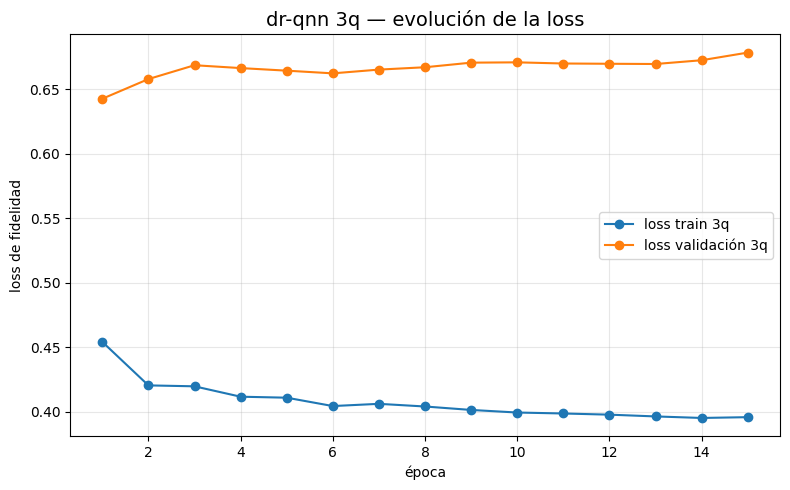

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(historial_3q["epoch"], historial_3q["loss_train"], marker="o", label="loss train 3q")
plt.plot(historial_3q["epoch"], historial_3q["loss_val"], marker="o", label="loss validación 3q")

plt.title("dr-qnn 3q — evolución de la loss", fontsize=14)
plt.xlabel("época")
plt.ylabel("loss de fidelidad")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

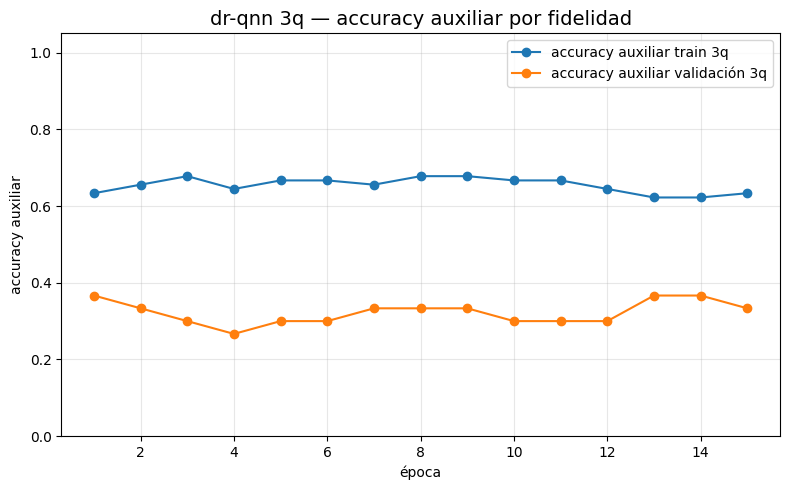

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(historial_3q["epoch"], historial_3q["acc_train"], marker="o", label="accuracy auxiliar train 3q")
plt.plot(historial_3q["epoch"], historial_3q["acc_val"], marker="o", label="accuracy auxiliar validación 3q")

plt.title("dr-qnn 3q — accuracy auxiliar por fidelidad", fontsize=14)
plt.xlabel("época")
plt.ylabel("accuracy auxiliar")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Comparación de curvas 1q vs 2q vs 3q:**

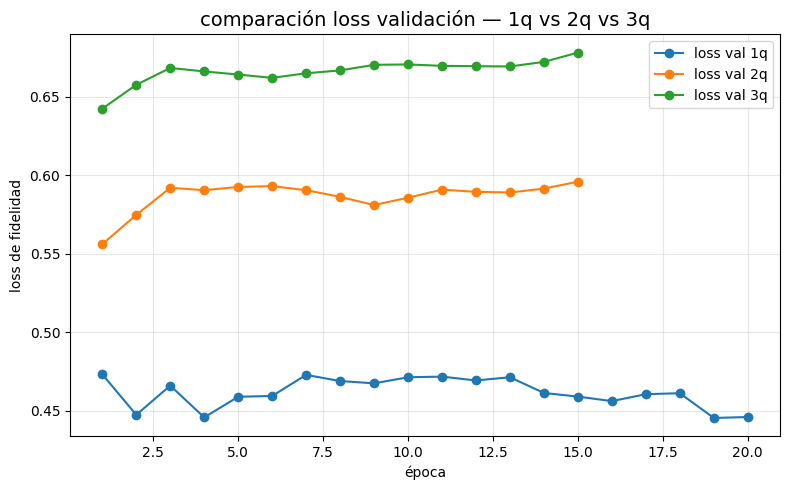

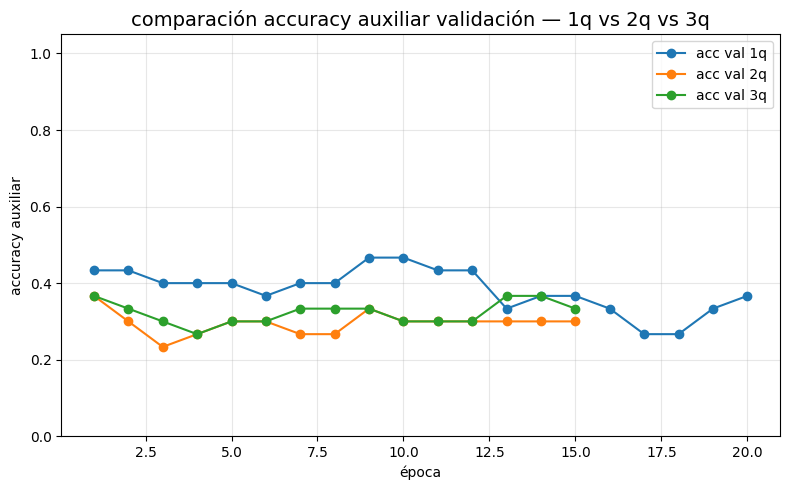

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["loss_val"], marker="o", label="loss val 1q")
plt.plot(historial_2q["epoch"], historial_2q["loss_val"], marker="o", label="loss val 2q")
plt.plot(historial_3q["epoch"], historial_3q["loss_val"], marker="o", label="loss val 3q")

plt.title("comparación loss validación — 1q vs 2q vs 3q", fontsize=14)
plt.xlabel("época")
plt.ylabel("loss de fidelidad")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(historial_1q["epoch"], historial_1q["acc_val"], marker="o", label="acc val 1q")
plt.plot(historial_2q["epoch"], historial_2q["acc_val"], marker="o", label="acc val 2q")
plt.plot(historial_3q["epoch"], historial_3q["acc_val"], marker="o", label="acc val 3q")

plt.title("comparación accuracy auxiliar validación — 1q vs 2q vs 3q", fontsize=14)
plt.xlabel("época")
plt.ylabel("accuracy auxiliar")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Matriz de confusión en test 3q:**

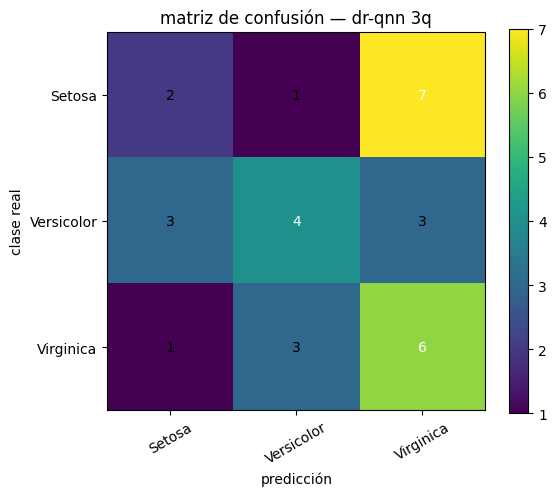

In [94]:
cm_3q = confusion_matrix(y_test_real_3q, y_test_pred_3q)

plt.figure(figsize=(6, 5))
plt.imshow(cm_3q, interpolation="nearest")
plt.title("matriz de confusión — dr-qnn 3q")
plt.colorbar()

ticks = np.arange(N_CLASES)

plt.xticks(ticks, [NOMBRES_CLASES[i] for i in range(N_CLASES)], rotation=30)
plt.yticks(ticks, [NOMBRES_CLASES[i] for i in range(N_CLASES)])

for i in range(N_CLASES):
    for j in range(N_CLASES):
        plt.text(j,i,cm_3q[i, j],ha="center",va="center",color="white" if cm_3q[i, j] > cm_3q.max() / 2 else "black")

plt.xlabel("predicción")
plt.ylabel("clase real")
plt.tight_layout()
plt.show()


**Reporte de clasificación en test 3q:**

In [95]:
print("\nreporte de clasificación — test 3q")
print("-" * 60)

print(classification_report(y_test_real_3q,y_test_pred_3q,target_names=[NOMBRES_CLASES[i] for i in range(N_CLASES)]))


reporte de clasificación — test 3q
------------------------------------------------------------
              precision    recall  f1-score   support

      Setosa       0.33      0.20      0.25        10
  Versicolor       0.50      0.40      0.44        10
   Virginica       0.38      0.60      0.46        10

    accuracy                           0.40        30
   macro avg       0.40      0.40      0.39        30
weighted avg       0.40      0.40      0.39        30



**Obtener embeddings |ψθ(x)> del modelo 3q:**

In [96]:
psi_train_3q, y_train_emb_3q = obtener_embeddings(modelo_3q, train_loader)
psi_val_3q, y_val_emb_3q = obtener_embeddings(modelo_3q, val_loader)
psi_test_3q, y_test_emb_3q = obtener_embeddings(modelo_3q, test_loader)

print("\nembeddings generados con θ*_3q y φ*_3q")
print("-" * 60)
print("psi_train_3q:", psi_train_3q.shape)
print("psi_val_3q:  ", psi_val_3q.shape)
print("psi_test_3q: ", psi_test_3q.shape)


embeddings generados con θ*_3q y φ*_3q
------------------------------------------------------------
psi_train_3q: torch.Size([90, 8])
psi_val_3q:   torch.Size([30, 8])
psi_test_3q:  torch.Size([30, 8])


**Convertir estado 3q a bloch del primer qubit:**

In [97]:
def estado_nq_a_bloch_qubit_0(estado, n_qubits):
    psi = np.asarray(estado, dtype=np.complex128).reshape(2, -1)

    rho_0 = psi @ np.conjugate(psi).T

    rx = 2 * np.real(rho_0[0, 1])
    ry = -2 * np.imag(rho_0[0, 1])
    rz = np.real(rho_0[0, 0] - rho_0[1, 1])

    return float(rx), float(ry), float(rz)


def batch_estados_nq_a_bloch_qubit_0(psi_batch, n_qubits):
    psi_np = psi_batch.numpy()

    coords = []

    for estado in psi_np:
        coords.append(estado_nq_a_bloch_qubit_0(estado, n_qubits))

    return np.array(coords)


bloch_train_3q = batch_estados_nq_a_bloch_qubit_0(psi_train_3q, n_qubits=3)
bloch_val_3q = batch_estados_nq_a_bloch_qubit_0(psi_val_3q, n_qubits=3)
bloch_test_3q = batch_estados_nq_a_bloch_qubit_0(psi_test_3q, n_qubits=3)

print("\ncoordenadas de bloch reducidas del primer qubit")
print("-" * 60)
print("bloch_train_3q:", bloch_train_3q.shape)
print("bloch_val_3q:  ", bloch_val_3q.shape)
print("bloch_test_3q: ", bloch_test_3q.shape)


coordenadas de bloch reducidas del primer qubit
------------------------------------------------------------
bloch_train_3q: (90, 3)
bloch_val_3q:   (30, 3)
bloch_test_3q:  (30, 3)


**Visualizar embeddings 3q en esfera de bloch reducida:**

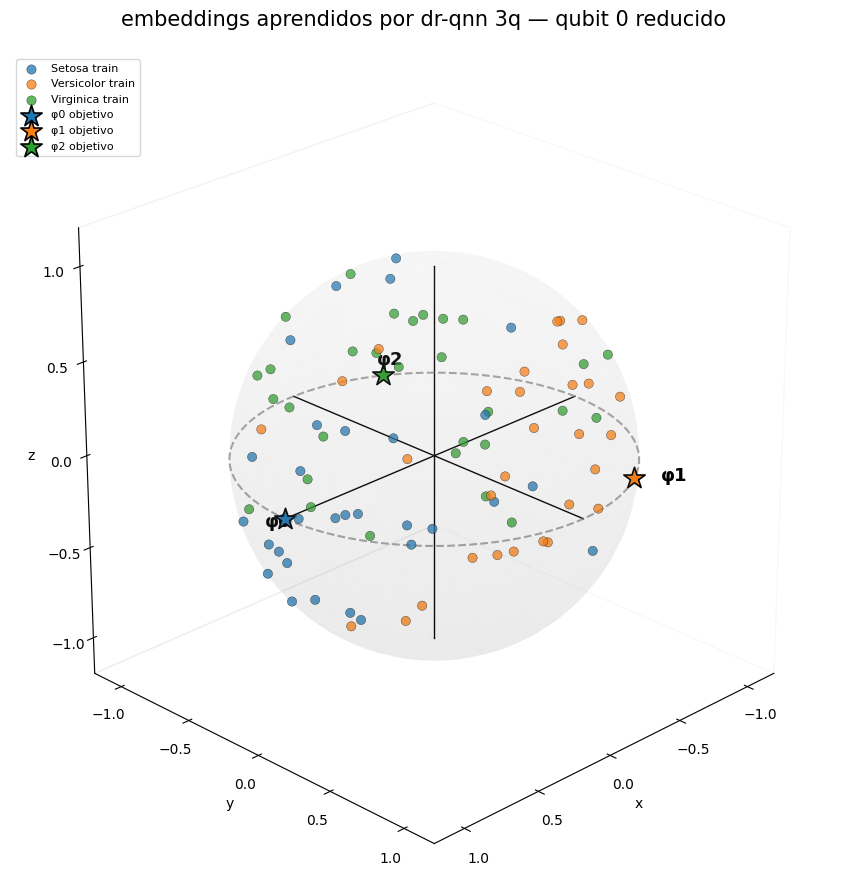

In [98]:
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 60)

x_esfera = np.outer(np.cos(u), np.sin(v))
y_esfera = np.outer(np.sin(u), np.sin(v))
z_esfera = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x_esfera, y_esfera, z_esfera, alpha=0.06, color="lightgray", linewidth=0)

ax.plot([-1, 1], [0, 0], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [-1, 1], [0, 0], color="black", linewidth=1)
ax.plot([0, 0], [0, 0], [-1, 1], color="black", linewidth=1)

ax.plot(np.cos(u), np.sin(u), np.zeros_like(u), linestyle="--", linewidth=1.5, color="gray", alpha=0.7)

for clase_id in range(N_CLASES):
    mascara = y_train_emb_3q.numpy() == clase_id

    ax.scatter(
        bloch_train_3q[mascara, 0],
        bloch_train_3q[mascara, 1],
        bloch_train_3q[mascara, 2],
        s=45,
        alpha=0.75,
        color=COLORES_CLASES[clase_id],
        edgecolors="black",
        linewidth=0.3,
        label=f"{NOMBRES_CLASES[clase_id]} train"
    )

for clase_id in range(N_CLASES):
    rx, ry, rz = estados_bloch[clase_id]

    ax.scatter(
        rx,
        ry,
        rz,
        s=260,
        color=COLORES_CLASES[clase_id],
        edgecolors="black",
        linewidth=1.2,
        marker="*",
        label=f"φ{clase_id} objetivo"
    )

    ax.text(
        1.13 * rx,
        1.13 * ry,
        1.13 * rz,
        f"φ{clase_id}",
        fontsize=13,
        weight="bold"
    )

ax.set_title("embeddings aprendidos por dr-qnn 3q — qubit 0 reducido", fontsize=15, pad=20)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.grid(False)
ax.view_init(elev=25, azim=45)

ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

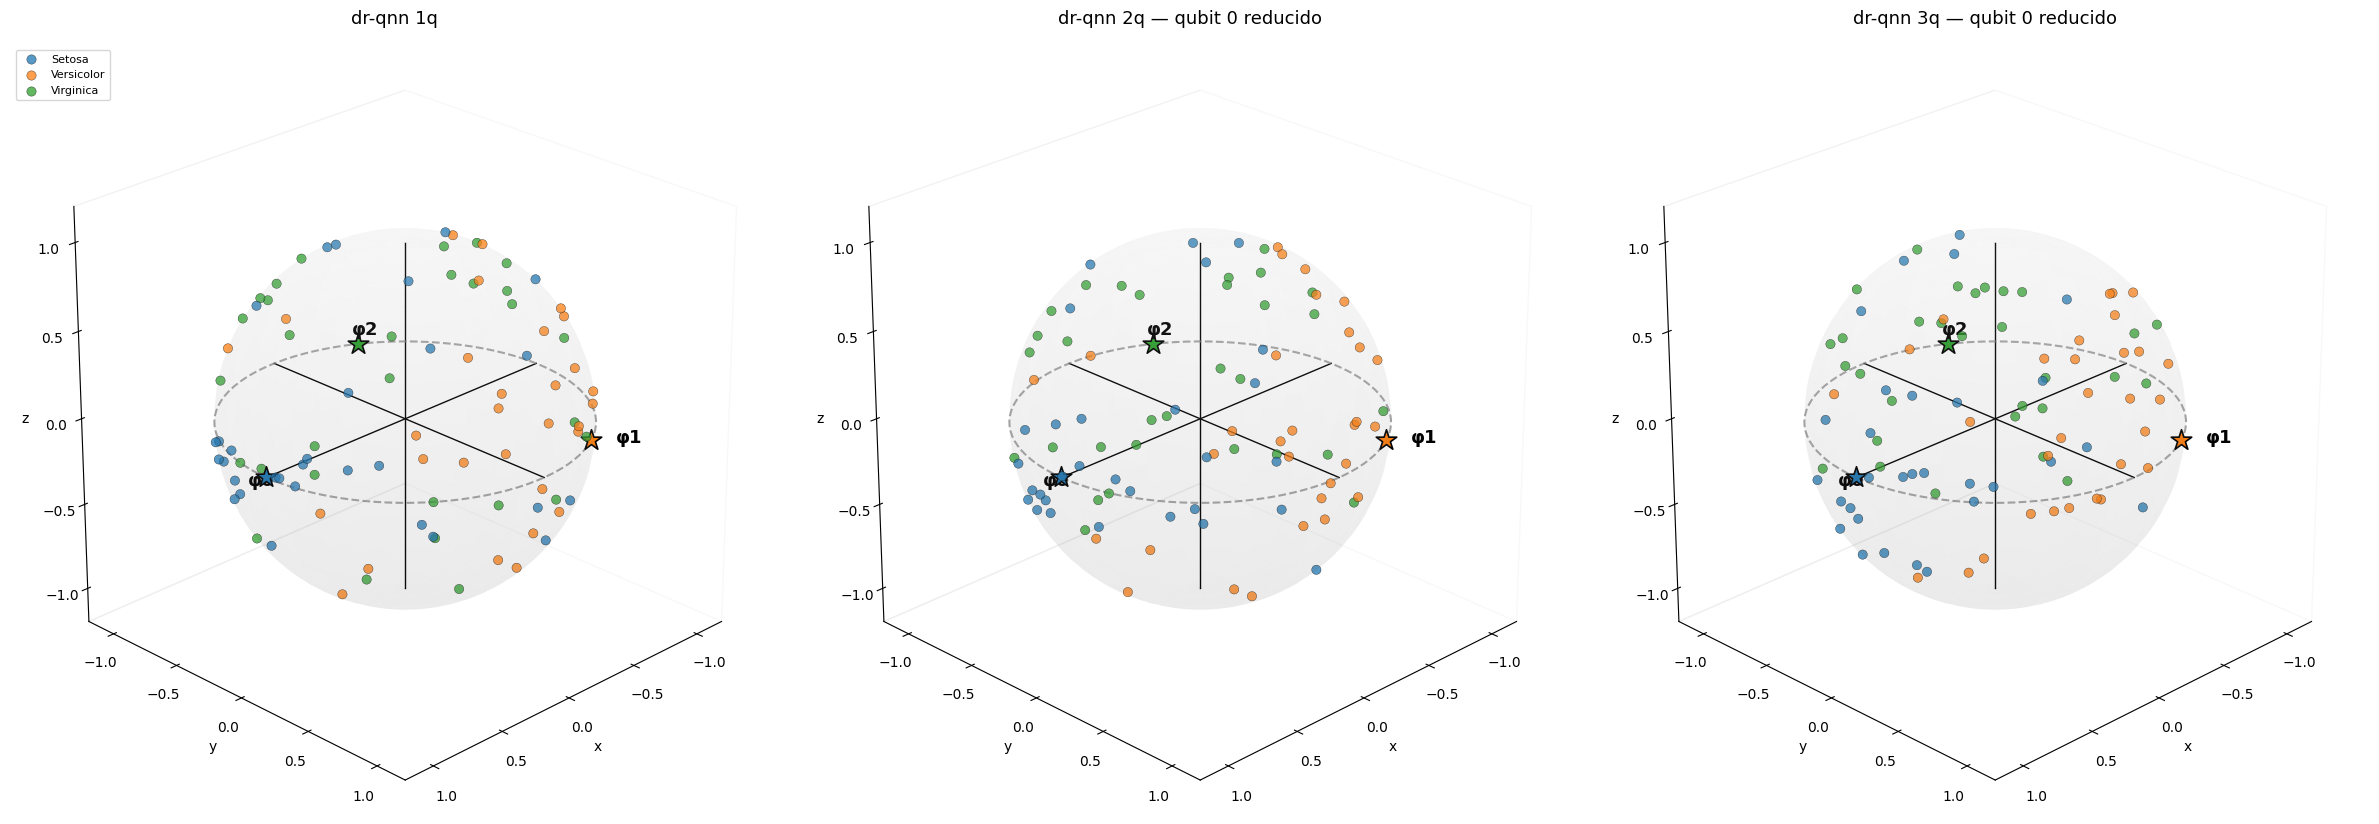

In [99]:
fig = plt.figure(figsize=(24, 8))

ax1 = fig.add_subplot(131, projection="3d")
ax2 = fig.add_subplot(132, projection="3d")
ax3 = fig.add_subplot(133, projection="3d")

for ax, bloch_data, y_emb, titulo in [
    (ax1, bloch_train_1q, y_train_emb_1q, "dr-qnn 1q"),
    (ax2, bloch_train_2q, y_train_emb_2q, "dr-qnn 2q — qubit 0 reducido"),
    (ax3, bloch_train_3q, y_train_emb_3q, "dr-qnn 3q — qubit 0 reducido")
]:

    ax.plot_surface(x_esfera, y_esfera, z_esfera, alpha=0.06, color="lightgray", linewidth=0)

    ax.plot([-1, 1], [0, 0], [0, 0], color="black", linewidth=1)
    ax.plot([0, 0], [-1, 1], [0, 0], color="black", linewidth=1)
    ax.plot([0, 0], [0, 0], [-1, 1], color="black", linewidth=1)

    ax.plot(np.cos(u), np.sin(u), np.zeros_like(u), linestyle="--", linewidth=1.5, color="gray", alpha=0.7)

    for clase_id in range(N_CLASES):
        mascara = y_emb.numpy() == clase_id

        ax.scatter(
            bloch_data[mascara, 0],
            bloch_data[mascara, 1],
            bloch_data[mascara, 2],
            s=45,
            alpha=0.75,
            color=COLORES_CLASES[clase_id],
            edgecolors="black",
            linewidth=0.3,
            label=NOMBRES_CLASES[clase_id]
        )

    for clase_id in range(N_CLASES):
        rx, ry, rz = estados_bloch[clase_id]

        ax.scatter(
            rx,
            ry,
            rz,
            s=240,
            color=COLORES_CLASES[clase_id],
            edgecolors="black",
            linewidth=1.2,
            marker="*"
        )

        ax.text(
            1.13 * rx,
            1.13 * ry,
            1.13 * rz,
            f"φ{clase_id}",
            fontsize=13,
            weight="bold"
        )

    ax.set_title(titulo, fontsize=13, pad=15)

    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.grid(False)
    ax.view_init(elev=25, azim=45)

ax1.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

**Resumen final:**

In [100]:
resumen_3q = {
    "modelo": "dr-qnn 3q",
    "n_qubits": 3,
    "dim_estado": modelo_3q.dimension_estado,
    "parametros": contar_parametros(modelo_3q),
    "loss_train": loss_train_3q,
    "acc_train_aux": acc_train_3q,
    "loss_val": loss_val_3q,
    "acc_val_aux": acc_val_3q,
    "loss_test": loss_test_3q,
    "acc_test_aux": acc_test_3q,
    "tiempo_promedio_epoca": np.mean(historial_3q["tiempo_epoca"]),
    "tiempo_total": np.sum(historial_3q["tiempo_epoca"])
}

print("\nresumen modelo 3q")
print("-" * 60)

for clave, valor in resumen_3q.items():
    print(f"{clave}: {valor}")

print("\ncomparación rápida 1q vs 2q vs 3q")
print("-" * 60)
print(f"1q test -> loss: {loss_test_1q:.6f} | acc auxiliar: {acc_test_1q:.4f}")
print(f"2q test -> loss: {loss_test_2q:.6f} | acc auxiliar: {acc_test_2q:.4f}")
print(f"3q test -> loss: {loss_test_3q:.6f} | acc auxiliar: {acc_test_3q:.4f}")

print("\nsección 9 completada")
print("-" * 60)
print("modelo 3q entrenado desde θ*_2q y φ*_2q.")
print("θ*_3q y φ*_3q guardados.")
print("embeddings 3q proyectados a bloch mediante ρ^(1).")
print("siguiente sección: tabla comparativa final de 1q, 2q y 3q.")


resumen modelo 3q
------------------------------------------------------------
modelo: dr-qnn 3q
n_qubits: 3
dim_estado: 8
parametros: 90
loss_train: 0.3918010038664194
acc_train_aux: 0.6666666666666666
loss_val: 0.67824174933642
acc_val_aux: 0.3333333333333333
loss_test: 0.5548338197688413
acc_test_aux: 0.4
tiempo_promedio_epoca: 11.20227147738139
tiempo_total: 168.03407216072083

comparación rápida 1q vs 2q vs 3q
------------------------------------------------------------
1q test -> loss: 0.438896 | acc auxiliar: 0.3667
2q test -> loss: 0.517143 | acc auxiliar: 0.4333
3q test -> loss: 0.554834 | acc auxiliar: 0.4000

sección 9 completada
------------------------------------------------------------
modelo 3q entrenado desde θ*_2q y φ*_2q.
θ*_3q y φ*_3q guardados.
embeddings 3q proyectados a bloch mediante ρ^(1).
siguiente sección: tabla comparativa final de 1q, 2q y 3q.


In [102]:
def evaluar_directo_sin_loader(modelo, X, y, nombre):
    modelo.eval()

    with torch.no_grad():
        psi = modelo(X)
        fid = fidelidades_todas_las_clases(psi, y, modelo.n_qubits) if False else fidelidades_todas_las_clases(psi, modelo.n_qubits)
        pred = torch.argmax(fid, dim=1)
        acc = (pred == y).float().mean().item()

    print("\n" + "="*70)
    print(nombre)
    print("="*70)
    print("accuracy:", acc)
    print("clases reales:", torch.bincount(y, minlength=N_CLASES).detach().cpu().numpy())
    print("clases pred:  ", torch.bincount(pred, minlength=N_CLASES).detach().cpu().numpy())

    print("\nfidelidad media por clase real:")
    for c in range(N_CLASES):
        mask = y == c
        print(f"{c} {NOMBRES_CLASES[c]:10s} ->", fid[mask].mean(dim=0).detach().cpu().numpy())

    print("\nmatriz de confusión:")
    print(confusion_matrix(y.detach().cpu().numpy(), pred.detach().cpu().numpy()))

    return pred, fid


# 1 qubit
pred_train_1q_dir, fid_train_1q_dir = evaluar_directo_sin_loader(
    modelo_1q, X_train_t, y_train_t, "TRAIN directo 1q"
)

pred_val_1q_dir, fid_val_1q_dir = evaluar_directo_sin_loader(
    modelo_1q, X_val_t, y_val_t, "VAL directo 1q"
)

pred_test_1q_dir, fid_test_1q_dir = evaluar_directo_sin_loader(
    modelo_1q, X_test_t, y_test_t, "TEST directo 1q"
)


# 2 qubits
pred_train_2q_dir, fid_train_2q_dir = evaluar_directo_sin_loader(
    modelo_2q, X_train_t, y_train_t, "TRAIN directo 2q"
)

pred_val_2q_dir, fid_val_2q_dir = evaluar_directo_sin_loader(
    modelo_2q, X_val_t, y_val_t, "VAL directo 2q"
)

pred_test_2q_dir, fid_test_2q_dir = evaluar_directo_sin_loader(
    modelo_2q, X_test_t, y_test_t, "TEST directo 2q"
)


# 3 qubits
pred_train_3q_dir, fid_train_3q_dir = evaluar_directo_sin_loader(
    modelo_3q, X_train_t, y_train_t, "TRAIN directo 3q"
)

pred_val_3q_dir, fid_val_3q_dir = evaluar_directo_sin_loader(
    modelo_3q, X_val_t, y_val_t, "VAL directo 3q"
)

pred_test_3q_dir, fid_test_3q_dir = evaluar_directo_sin_loader(
    modelo_3q, X_test_t, y_test_t, "TEST directo 3q"
)


TRAIN directo 1q
accuracy: 0.6333333253860474
clases reales: [30 30 30]
clases pred:   [28 31 31]

fidelidad media por clase real:
0 Setosa     -> [0.67517429 0.37865673 0.44616946]
1 Versicolor -> [0.34510633 0.70229811 0.45259608]
2 Virginica  -> [0.37899784 0.42552916 0.69547347]

matriz de confusión:
[[19  4  7]
 [ 4 20  6]
 [ 5  7 18]]

VAL directo 1q
accuracy: 0.36666667461395264
clases reales: [10 10 10]
clases pred:   [ 9 12  9]

fidelidad media por clase real:
0 Setosa     -> [0.55530759 0.36660066 0.57809223]
1 Versicolor -> [0.51787467 0.60650871 0.37561686]
2 Virginica  -> [0.40067762 0.59915345 0.50016935]

matriz de confusión:
[[4 1 5]
 [3 5 2]
 [2 6 2]]

TEST directo 1q
accuracy: 0.36666667461395264
clases reales: [10 10 10]
clases pred:   [ 7  6 17]

fidelidad media por clase real:
0 Setosa     -> [0.50176309 0.42604708 0.57219017]
1 Versicolor -> [0.30492189 0.57216548 0.6229131 ]
2 Virginica  -> [0.42084079 0.46977748 0.60938209]

matriz de confusión:
[[3 3 4]
 [1 2 